# UT8: Modelado Predictivo - Introducción al Machine Learning

Análisis de datos con Python

# UT8: Modelado y *Machine Learning*

> **Cuaderno de trabajo — UT8: Machine Learning Básico**
>
> Este notebook contiene los ejercicios de la unidad. Para la teoría
> completa consulta el libro (PDF).

**Manos a la Obra**

**Identificar tipo de problema ML**

**Objetivo:** practicar la identificación de tipos de aprendizaje
automático a partir de problemas empresariales reales.

Para cada problema de negocio, indica: (1) tipo de aprendizaje
(supervisado / no supervisado / refuerzo), (2) si es supervisado:
¿clasificación o regresión?, y (3) qué variables actuarían como $X$ y
cuál como $y$ (si aplica):

A. Una aseguradora quiere predecir el coste anual de reclamaciones de
cada cliente. B. Netflix quiere agrupar usuarios con gustos similares
para ofrecerles recomendaciones. C. Un banco quiere determinar si
aprobar o rechazar una solicitud de crédito. D. Idealista quiere estimar
el precio de alquiler de un piso. E. Una teleco quiere identificar
clientes que abandonarán el servicio el próximo mes.

**Criterio de éxito:** para cada caso has identificado el tipo de
aprendizaje, si es supervisado el subtipo (clasificación o regresión), y
has justificado qué columnas serían $X$ y cuál sería $y$. Contrasta tus
respuestas con el profesor o consulta el fichero de soluciones.

**Dificultad:** básico

**Manos a la Obra**

### ordenar el flujo ML

**Objetivo:** consolidar la comprensión del flujo de trabajo profesional
en un proyecto de ML.

**Escenario:** Un banco te contrata para predecir qué clientes
incumplirán pagos de préstamos. Tienes acceso a 50.000 registros
históricos con datos de ingresos, historial crediticio y comportamiento
de pago.

1.  Ordena las siguientes acciones según el flujo correcto de ML (1-8):
    -   [ ] Evaluar el rendimiento del modelo con los datos de test.
    -   [ ] Separar los datos en conjunto de entrenamiento y conjunto de
        test.
    -   [ ] Identificar que es un problema de clasificación binaria
        (cumple / incumple).
    -   [ ] Entrenar el modelo con el conjunto de entrenamiento.
    -   [ ] Analizar la distribución de la variable objetivo (¿cuántos
        clientes cumplen y cuántos incumplen?).
    -   [ ] Presentar los resultados y recomendaciones al equipo de
        negocio.
    -   [ ] Imputar los valores nulos en “ingresos_anuales”.
    -   [ ] Integrar el modelo en el sistema de evaluación de crédito y
        supervisar su precisión mensualmente.
2.  ¿Por qué la separación train/test debe hacerse antes de entrenar el
    modelo pero después de identificar el problema?
3.  ¿Qué riesgos aparecen si entrenas el modelo antes de explorar los
    datos?
4.  ¿Por qué la presentación de resultados es tan parte del trabajo como
    el modelado técnico?

**Criterio de éxito:** has ordenado correctamente las 8 etapas
respetando la regla de que el *train/test split* va siempre antes del
entrenamiento, y has justificado cada una de las preguntas de análisis.
Contrasta tu ordenación con el profesor o consulta el fichero de
soluciones.

**Dificultad:** básico

Tienes dos columnas: `MonthlyIncome` (rango: 1.000–15.000 €) y
`YearsExperience` (rango: 0–40 años). Ambas se usan para predecir si un
empleado abandonará la empresa (clasificación binaria).

1.  Sin escalar, ¿cuál de las dos variables tendría mayor influencia
    numérica en el cálculo de $z = \beta_1 X_1 + \beta_2 X_2$ de la
    Regresión Logística? ¿Es eso un reflejo de su importancia real?
2.  Después de aplicar `StandardScaler`, ¿qué valores tendrá la media y
    la desviación estándar de cada columna transformada?
3.  Si en lugar de Regresión Logística usaras un
    `RandomForestClassifier`, ¿necesitarías incluir el `StandardScaler`
    en el `Pipeline`? ¿Por qué los árboles son invariantes al escalado?

**Manos a la Obra**

### Preparación de Datos Completa

**Objetivo:** Practicar el pipeline completo de preparación con
train/test split correcto.

Estás diseñando el pipeline de preparación para un cliente que te
entrega datos de viviendas sin limpiar. Las columnas tienen esta
naturaleza: `GarageArea` (numérica, contiene nulos en casas sin garaje),
`GrLivArea` (numérica, sin nulos), `Neighborhood` (nominal: 25 barrios),
`ExterQual` (ordinal: Fa \< TA \< Gd \< Ex) y `PriceCategory` (objetivo:
4 categorías de precio).

1.  Determina el ORDEN CORRECTO de las siguientes operaciones: Separar
    $X$ e $y$, Train/test split, Imputar nulos en `GarageArea`,
    Codificar `Neighborhood`, Codificar `ExterQual`, Escalar
    `GarageArea` y `GrLivArea`.
2.  ¿En qué paso haces el train/test split? ¿Antes o después de imputar?
3.  ¿Usas `.fit_transform()` o `.transform()` en el test set? ¿Por qué?
4.  ¿Qué tipo de scaler usarías para `GarageArea` y `GrLivArea`?
    Justifica.

La secuencia de preparación es fundamental en ML. Tienes un resumen de
transformadores en el **Apéndice C.4**.

**Dificultad:** básico

In [18]:
# Escribe tu codigo aqui

## Regresión Lineal: el modelo más interpretable

Con los datos preparados y el split en su sitio, estamos listos para
entrenar el primer modelo.

La regresión lineal es el algoritmo de ML supervisado más antiguo, más
estudiado y más usado en la industria. No es el más potente, pero sí el
más interpretable: sus resultados se pueden explicar directamente en
términos de negocio (“cada metro cuadrado adicional añade X€ al
precio”), lo que lo convierte en el punto de partida obligatorio de
cualquier problema de regresión. Además, entender la regresión lineal es
entender la intuición matemática detrás de muchos algoritmos más
complejos.

### Intuición y Concepto

La regresión lineal encuentra la línea recta que mejor representa la
relación entre una o más variables predictoras ($X$) y una variable
objetivo continua ($y$):

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$

Donde:

-   $y$: variable objetivo (lo que queremos predecir).
-   $X_1, X_2, \dots, X_n$: variables predictoras (*features*).
-   $\beta_0$: intercepto (valor de $y$ cuando todas las $X$ son 0).
-   $\beta_1, \beta_2, \dots, \beta_n$: coeficientes (peso de cada
    *feature*).
-   $\epsilon$: error/residuo.

La ventaja distintiva de la regresión lineal es la interpretabilidad
directa de sus coeficientes: cada $\beta_i$ indica exactamente cuánto
varía $y$ por cada unidad de cambio en $X_i$. Si $\beta_1 = 150$ para
metros cuadrados, el modelo dice que por cada metro cuadrado adicional
el precio sube 150 €. Es la información más fácil de trasladar a un
cliente o responsable no técnico.

| Úsala cuando…                                                  | Evítala cuando…                                           |
|----------------------------------|--------------------------------------|
| La relación entre $X$ e $y$ es aproximadamente lineal          | La relación es marcadamente no lineal                     |
| Necesitas explicar el modelo a personas no técnicas            | Solo importa la precisión predictiva, no la explicación   |
| Quieres un *baseline* rápido antes de probar modelos complejos | Hay *outliers* extremos que penalizan el error cuadrático |
| Los datos no tienen *outliers* extremos                        | —                                                         |

Guía de uso de la regresión lineal

Cuando la regresión lineal sea la elección adecuada, su implementación
en Scikit-learn es directa.

**¿Por qué predecimos `log_SalePrice` y no `SalePrice` directamente?**
`SalePrice` tiene asimetría (skew ≈ 1,88): los errores del modelo serían
sistemáticamente mayores en viviendas caras y menores en baratas
(heteroscedasticidad). Modelar el logaritmo del precio, que tiene
distribución casi simétrica (skew ≈ 0,12), elimina ese sesgo y mejora
tanto las métricas como la interpretabilidad de los coeficientes — que
ahora expresan cambios porcentuales en el precio. Las predicciones
finales se recuperan en euros con `np.exp(predicción)`.

### Implementación en Scikit-learn

`LinearRegression` sigue el mismo patrón `fit`/`predict` presentado al
inicio de la unidad. A diferencia de los árboles — que toman decisiones
por umbrales sobre cada variable de forma independiente y son
invariantes a la escala — la regresión lineal opera sobre sumas
ponderadas ($z = \beta_1 X_1 + \beta_2 X_2 + \dots$), por lo que una
variable con rango 0–100.000 dominaría numéricamente sobre otra con
rango 0–10 aunque su relevancia real sea menor. Escalar con
`StandardScaler` es imprescindible para que los coeficientes sean
comparables entre sí:

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_lr  = StandardScaler()
X_train_lr = pd.DataFrame(scaler_lr.fit_transform(X_train),
                           columns=FEATURES, index=X_train.index)
X_test_lr  = pd.DataFrame(scaler_lr.transform(X_test),
                           columns=FEATURES, index=X_test.index)

modelo_lr = LinearRegression()   # sin hiperparámetros: determinístico
modelo_lr.fit(X_train_lr, y_train)

### Interpretación de coeficientes

La principal ventaja de la regresión lineal frente a otros algoritmos es
que sus resultados se pueden explicar directamente: cada coeficiente
cuantifica el efecto de una variable sobre el precio, manteniendo el
resto constante. Acceder a ellos y visualizarlos es una habilidad
profesional clave:

``` python
y_pred_lr      = modelo_lr.predict(X_test_lr)
y_pred_lr_euro = np.exp(y_pred_lr)   # back-transform a € para las métricas
y_test_euro    = np.exp(y_test)
print(f"**RMSE:** {mean_squared_error(y_test_euro, y_pred_lr_euro)**0.5:,.0f} $  ")
print(f"**R² (escala log):** {r2_score(y_test, y_pred_lr):.3f}\n")

coef_df = (pd.DataFrame({'feature': X_train_lr.columns,
                          'coeficiente': modelo_lr.coef_})
             .sort_values('coeficiente', key=abs, ascending=False))
print(coef_df.to_markdown(index=False))
```

**RMSE:** 27,831 \$  
**R² (escala log):** 0.852

| feature          | coeficiente |
|:-----------------|------------:|
| log_GrLivArea    |     0.13595 |
| OverallQual      |    0.101946 |
| Neighborhood_enc |   0.0694589 |
| TotalBsmtSF      |   0.0693174 |
| GarageArea       |    0.050201 |
| YearBuilt        |   0.0448559 |

El modelo explica el **85%** de la varianza del log-precio de venta. El
error típico de predicción es **27,831 €**: en un caso promedio, el
modelo se equivoca en esa cantidad. Las dos variables con mayor peso son
`log_GrLivArea` (+14.6%/std) y `OverallQual` (+10.7%/std), confirmando
lo que el EDA de UT6 ya anticipaba con sus correlaciones más altas.

La tabla muestra los valores brutos; el barplot hace inmediata la
comparación relativa entre variables:

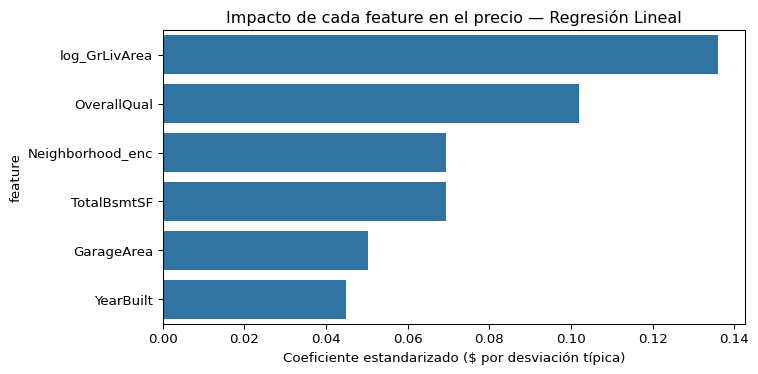

Este gráfico de barras es la «voz» del modelo. En general, los
coeficientes positivos (barras a la derecha) señalan factores que
aumentan el precio; los negativos (a la izquierda), factores que lo
penalizan. La longitud de la barra indica la potencia de ese factor: te
permite priorizar qué características investigar más a fondo o proponer
al negocio como palancas clave.

**Coeficientes parciales vs. correlación individual.** `YearBuilt` tiene
una correlación positiva con `SalePrice` (r ≈ 0,52), pero en el modelo
puede aparecer con coeficiente cercano a cero o incluso ligeramente
negativo. Esto no es un error: el coeficiente de regresión mide el
efecto *marginal* de una variable manteniendo el resto constante. Cuando
`OverallQual`, `Neighborhood_enc` y `TotalBsmtSF` ya están en el modelo,
capturan gran parte de la señal de «casa moderna y bien construida» que
`YearBuilt` tenía de forma individual. Lo que queda es su efecto puro
sobre el precio una vez descontados esos factores — que puede ser
pequeño o incluso invertido en ciertos segmentos del mercado.

El modelo predice `log_SalePrice`. Con `StandardScaler`, los
coeficientes estandarizados son: `log_GrLivArea = +0,136`,
`OverallQual = +0,093`, `TotalBsmtSF = +0,069`,
`Neighborhood_enc = +0,065`. La interpretación ya no es “\$ por
desviación típica” sino “unidades de log-precio por desviación típica”,
lo que equivale a un cambio porcentual en el precio:
$(\mathrm{e}^{\beta} - 1) \times 100\,\%$.

1.  El coeficiente de `log_GrLivArea` es +0,136. Eso significa que una
    desviación típica más de superficie multiplica el precio por
    $e^{0{,}136} \approx 1{,}146$, es decir, un **14,6 % más**. La
    desviación típica de `log_GrLivArea` en Ames es ≈ 0,325
    log-unidades, equivalente a ~38 % más de superficie. ¿Puedes
    calcular qué cambio porcentual en el precio corresponde a una
    desviación típica de `OverallQual`?
2.  El EDA de UT6 identificaba `OverallQual` como la variable con mayor
    correlación con `SalePrice` (r = 0,79), pero el modelo la sitúa en
    segundo lugar. ¿Qué puede explicar esa discrepancia entre la
    correlación individual y el coeficiente de regresión parcial?
3.  Si añadieras `GarageCars` junto a `GarageArea` (correlación r = 0,89
    entre ellas), ¿qué efecto podría tener eso sobre los coeficientes
    individuales de ambas variables? ¿Por qué la regla del EDA de UT6
    ($|r| > 0{,}8$ → eliminar una) es especialmente importante en
    regresión lineal?

### Métricas de evaluación para regresión

Interpretar los coeficientes responde al *por qué* predice el modelo.
Las métricas responden al *cuánto se equivoca* — y sin esa respuesta no
puedes comparar modelos ni decidir si uno es suficientemente bueno para
el problema.

Scikit-learn ofrece tres métricas para evaluar modelos de regresión,
cada una con un enfoque distinto sobre el error:

**MAE** (*Mean Absolute Error*): promedio de errores absolutos en la
misma unidad que $y$. Es la más directamente interpretable: si MAE =
20.000 \$, el modelo se equivoca de media en 20.000 \$.

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**RMSE** (*Root Mean Squared Error*): eleva los errores al cuadrado
antes de promediar, lo que penaliza desproporcionadamente los errores
grandes. Si el RMSE supera mucho al MAE, el modelo comete algunos
errores muy graves aunque en general sea aceptable.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

**$R^2$** (*coeficiente de determinación*): proporción de varianza de
$y$ explicada por el modelo — independientemente de la escala.
Recordarás de UT6 que calculaste el coeficiente de correlación $r$:
$R^2$ es literalmente $r^2$. Si $r = 0{,}9$, entonces $R^2 = 0{,}81$.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

La elección depende del contexto: MAE es la más directa para comunicar a
negocio; RMSE conviene cuando los errores grandes tienen consecuencias
especialmente graves; $R^2$ es la referencia para comparar modelos entre
sí. Sobre el modelo de Ames Housing ya entrenado:

In [23]:
mae_lr  = mean_absolute_error(y_test_euro, y_pred_lr_euro)   # back-transform a €
rmse_lr = mean_squared_error(y_test_euro, y_pred_lr_euro)**0.5
r2_lr   = r2_score(y_test, y_pred_lr)                       # R² en escala log (estándar)

| Métrica | Valor     | Interpretación                                                      |
|:---------|:--------|:----------------------------------------------------|
| MAE     | 19,705 \$ | Error medio de predicción                                           |
| RMSE    | 27,831 \$ | Penaliza errores grandes; RMSE \> MAE indica outliers de predicción |
| R²      | 0.852     | El modelo explica el 85% de la varianza del precio                  |

Métricas de evaluación — Regresión Lineal sobre Ames Housing.

**Comunicar métricas a negocio:**

$R^2$ es la métrica más fácil de comunicar a *stakeholders* no técnicos:
“el modelo captura el X% de los factores que determinan el precio” es
más claro que “RMSE de 34.000 \$”. Aprende a traducir métricas técnicas
a lenguaje de negocio: esa habilidad te diferenciará como profesional.

Un modelo de predicción del consumo eléctrico doméstico obtiene MAE =
0,8 kWh y $R^2$ = 0,72. Un modelo rival logra MAE = 1,3 kWh y $R^2$ =
0,88.

1.  ¿Cuál modelo elegirías si el objetivo es explicar ante la dirección
    qué porcentaje de la variabilidad en el consumo captura el modelo?
2.  ¿Cuál elegirías si el objetivo es facturar al cliente lo más cercano
    posible a su consumo real?
3.  ¿Es posible que un modelo con mayor $R^2$ tenga mayor MAE? ¿Qué lo
    explicaría?

### Análisis de residuos

Las métricas resumen el error global, pero no revelan *cómo* se equivoca
el modelo. Para eso sirve el análisis de residuos: la diferencia entre
el valor real y la predicción (`residuo = y_real - y_pred`). Si el
modelo es adecuado, los residuos se distribuyen aleatoriamente alrededor
de 0, sin ningún patrón visible.

In [25]:
residuos_lr = y_test - y_pred_lr

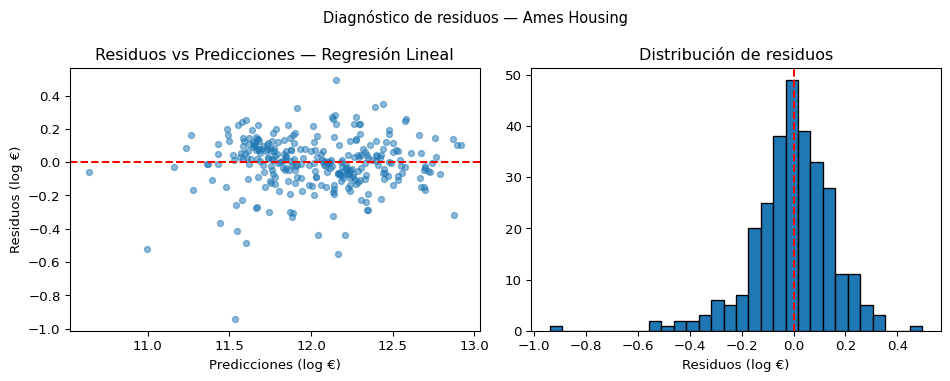

En el gráfico izquierdo buscas puntos dispersos aleatoriamente alrededor
de la línea roja (residuo = 0), sin ningún patrón. Una curva, un embudo
o un grupo de puntos alejados señala un problema — habitualmente que la
relación no es lineal y conviene probar otro algoritmo.

**Manos a la Obra**

### Regresión lineal aplicada

**Objetivo:** Implementar un pipeline completo de modelado predictivo,
desde la preparación de datos hasta el diagnóstico de residuos.

**Contexto profesional:** Trabajas en una inmobiliaria de Ames, Iowa. Tu
responsable quiere una herramienta que estime el precio de venta de una
vivienda a partir de sus características físicas. Usarás el mismo
*dataset* que limpiaste en UT5 y analizaste en UT6.

En este ejercicio usarás `SalePrice` directamente como objetivo para
simplificar la interpretación. El modelo del texto usa `log_SalePrice`
como buena práctica estadística; aquí priorizamos la legibilidad de las
métricas en euros.

**Instrucciones (Semi-guiado):**

1.  **Preparación:** Carga `house_prices_ml.csv` desde el repositorio
    del módulo. Selecciona `GrLivArea`, `OverallQual`, `YearBuilt` y
    `GarageArea` como predictores y `SalePrice` como objetivo. Aplica el
    *train/test split* (80/20, `random_state=42`).
2.  **Modelado:** Entrena un `LinearRegression` con `StandardScaler`.
    Aplica el escalado solo sobre los datos de entrenamiento para evitar
    *data leakage*.
3.  **Evaluación:** Calcula MAE, RMSE y $R^2$ sobre el conjunto de test.
4.  **Diagnóstico:** Genera el gráfico de coeficientes (barplot
    horizontal) y el análisis de residuos. ¿Cuál de las cuatro
    *features* tiene mayor impacto en el precio según el modelo?
5.  **Informe rápido:** ¿Coincide la *feature* más importante con el
    hallazgo del EDA de UT6?
6.  **Interpretación de negocio:** En una celda Markdown escribe 2-3
    frases respondiendo: ¿Qué significa un MAE de 26.200 \$ para una
    agencia inmobiliaria que quiere usar el modelo para tasar viviendas?
    ¿Es un margen de error aceptable o no? ¿En qué tipo de viviendas
    (baratas o caras) será el error proporcionalmente mayor?

**Criterio de éxito:** El código ejecuta sin errores y produce MAE ≈
26.200 \$, RMSE ≈ 34.000 \$, $R^2$ ≈ 0,79 (con `random_state=42` y
`StandardScaler`). La variable con mayor coeficiente estandarizado es
`GrLivArea` (+34.000 \$/desv.estándar), seguida de `OverallQual`
(+29.500 \$/desv.estándar) — las dos *features* con mayor correlación
con `SalePrice` en el EDA de UT6. La interpretación de negocio debe
mencionar explícitamente el MAE en términos de precio de vivienda, no
solo como número.

**Dificultad:** medio

In [27]:
# Escribe tu codigo aqui

## Clasificación: regresión logística

Con la regresión lineal dominada, el siguiente paso es abordar el otro
gran tipo de problema supervisado: predecir no un número, sino una
categoría.

La regresión lineal predice un valor continuo. Pero muchos problemas
reales no piden un número, sino una decisión: ¿este cliente abandonará o
no? ¿Este email es spam o no lo es? ¿Esta transacción es fraudulenta?
Para este tipo de problemas necesitamos un algoritmo de
**clasificación**, y la regresión logística es el punto de partida
natural: comparte la intuición matemática de la regresión lineal pero
añade el mecanismo que transforma una salida ilimitada en una
probabilidad acotada entre 0 y 1.

### De regresión a clasificación

A partir de ahora el objetivo es predecir categorías (clases) en lugar
de valores numéricos. Para introducir la clasificación con Ames Housing
transformaremos el problema: en lugar de predecir el precio exacto de
una vivienda (regresión), predeciremos si su precio está **por encima o
por debajo de la mediana del mercado** — una variable binaria (1 =
precio alto, 0 = precio bajo) que representa exactamente el tipo de
decisión que toma un comprador o un tasador.

A pesar de su nombre, la **regresión logística** es un algoritmo de
clasificación: predice la probabilidad de pertenencia a cada clase.

Su funcionamiento parte de la regresión lineal: calcula primero un valor
continuo ($z$):

$$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots$$

A continuación, aplica la **función sigmoide** para transformar $z$ en
una probabilidad acotada entre 0 y 1:

$$P(y=1) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots)}}$$

La regla de decisión convierte esa probabilidad en una clase:

$$
\hat{y} =
\begin{cases}
1 & \text{si } P(y=1) > 0.5 \\
0 & \text{si } P(y=1) \leq 0.5
\end{cases}
$$

El concepto clave es que la función sigmoide transforma una salida
lineal ilimitada en una probabilidad acotada entre 0 y 1.

<figure>
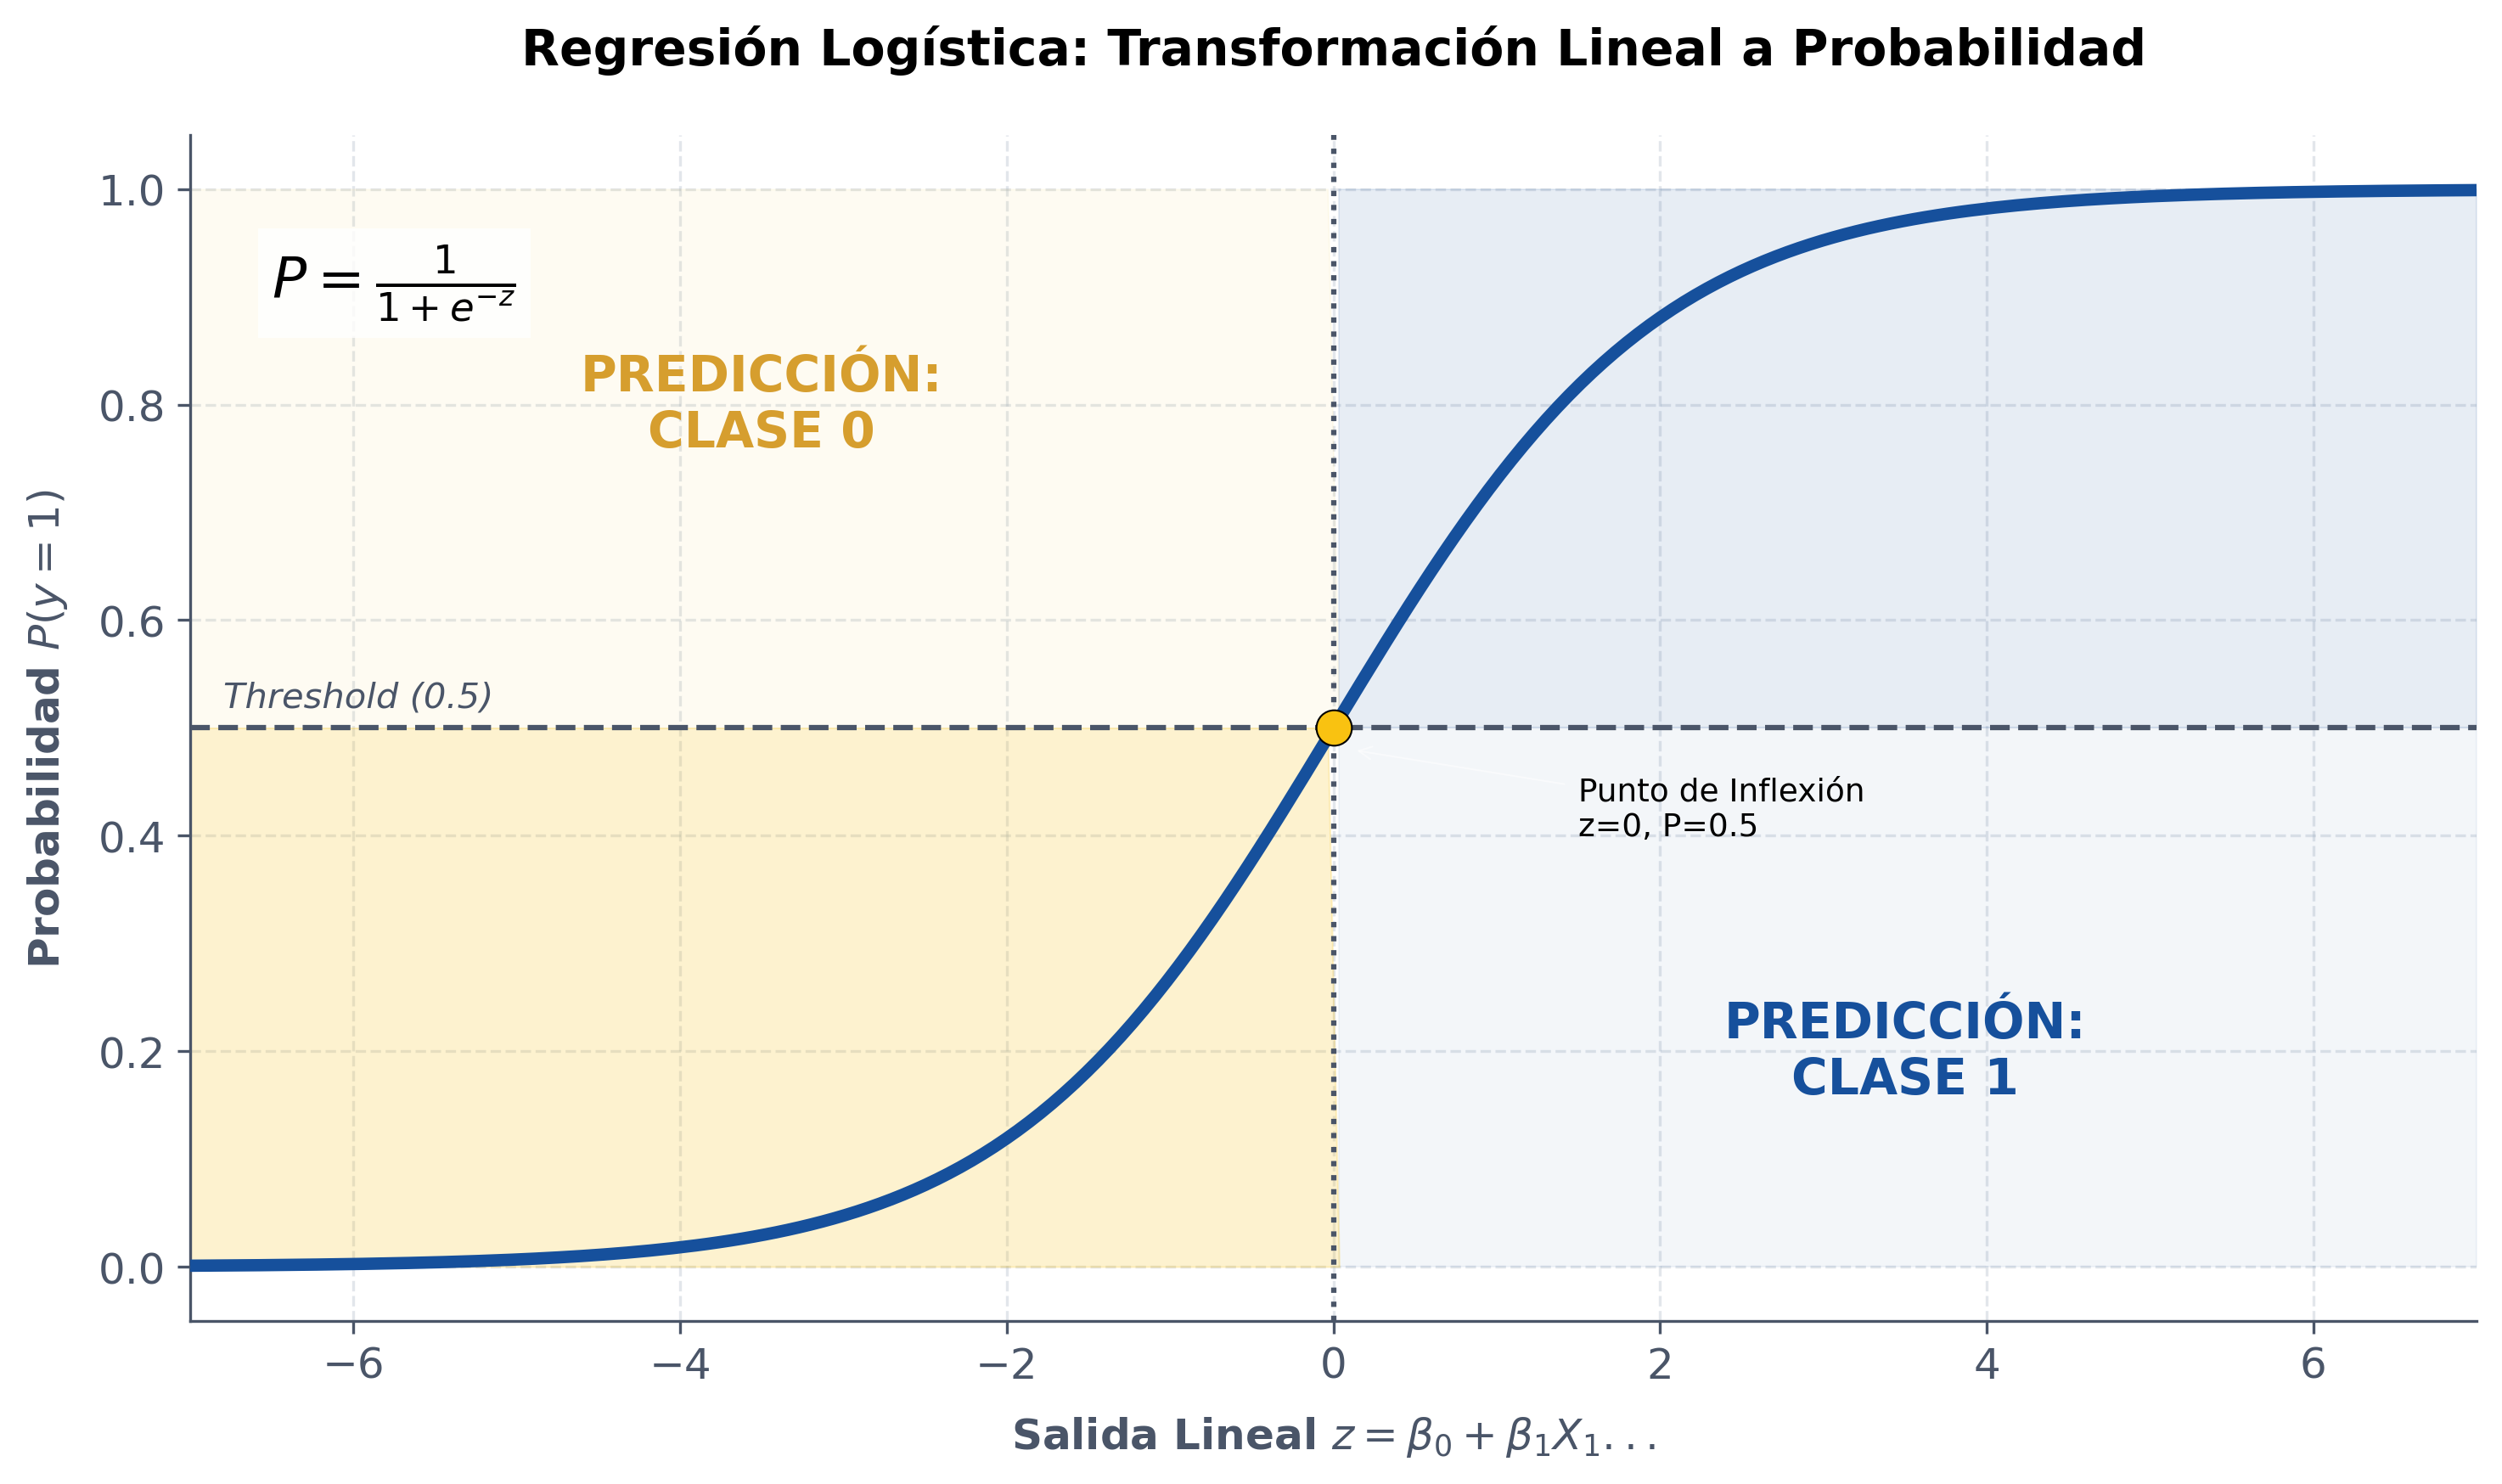
<figcaption aria-hidden="true">Regresión Logística</figcaption>
</figure>

La función sigmoide transforma cualquier valor real en una probabilidad
entre 0 y 1. Un modelo logístico calcula $z = 1{,}4$ para una vivienda
concreta.

1.  ¿Es esa probabilidad mayor o menor que 0,5? ¿Qué clase predice el
    modelo con el umbral por defecto?
2.  El equipo de *marketing* quiere ser conservador: solo catalogar como
    «precio alto» las viviendas de las que esté muy seguro. ¿Debería
    subir o bajar el umbral respecto al 0,5 por defecto? ¿Qué métrica de
    clasificación mejora y cuál empeora al hacer ese cambio?
3.  ¿Por qué no se puede usar directamente `LinearRegression` para
    predecir si el precio es alto o bajo? ¿Qué pasaría con sus
    predicciones para viviendas extremadamente baratas o extremadamente
    caras?

### Implementación en Scikit-learn

El código es prácticamente idéntico al de `LinearRegression`; la única
diferencia significativa es `.predict_proba()`, que devuelve la
probabilidad de cada clase en lugar de solo la clase final. Para
aplicarlo sobre Ames Housing transformamos el problema: predecir si una
vivienda tiene precio **por encima de la mediana del mercado**
(clasificación binaria).

In [29]:
# Target binario — mediana calculada solo sobre train para no filtrar
# información del test al modelo (data leakage)
mediana_precio = y_train.median()
y_train_clf = (y_train > mediana_precio).astype(int)
y_test_clf  = (y_test  > mediana_precio).astype(int)

In [30]:
modelo_log = LogisticRegression(random_state=42, max_iter=1000)
# StandardScaler escala features, no el target — es independiente de si predecimos
# un precio continuo o una clase binaria. Reutilizar X_train_lr (ajustado solo en train)
# es correcto: las features son las mismas y el escalado no cambia por el tipo de problema.
modelo_log.fit(X_train_lr, y_train_clf)

y_pred_clf  = modelo_log.predict(X_test_lr)
y_proba_clf = modelo_log.predict_proba(X_test_lr)

| P(precio bajo) | P(precio alto) | Clase predicha | Clase real |
|---------------:|---------------:|---------------:|-----------:|
|          0.005 |          0.995 |              1 |          1 |
|          0.994 |          0.006 |              0 |          0 |
|          0.994 |          0.006 |              0 |          0 |
|            0.7 |            0.3 |              0 |          0 |
|          0.001 |          0.999 |              1 |          1 |

Primeras 5 predicciones — probabilidades y clases (Regresión Logística).

**Evitar *warnings* de convergencia**

Siempre usa `max_iter=1000` o más para evitar *warnings* de
convergencia. Por defecto es 100, insuficiente para algunos *datasets*.
Si ves un `ConvergenceWarning`, aumenta `max_iter` o escala mejor tus
datos.

### Métricas de evaluación para clasificación

En regresión medíamos el error entre el valor predicho y el valor real
(MAE, RMSE, $R^2$). En clasificación la pregunta es distinta: no cuánto
nos hemos equivocado, sino **en qué tipo de error hemos caído**.
Predecir que un paciente sano está enfermo (falsa alarma) no tiene las
mismas consecuencias que predecir que un paciente enfermo está sano
(caso perdido). Las métricas de clasificación están diseñadas para
capturar exactamente esa distinción.

Las cuatro métricas principales son *accuracy* (exactitud), *precision*
(precisión), *recall* (exhaustividad o sensibilidad) y F1. Para entender
qué mide cada una necesitamos primero entender los cuatro tipos de
resultado posibles en clasificación binaria, que se resumen en la
**matriz de confusión**:

**La matriz de confusión:**

<figure>
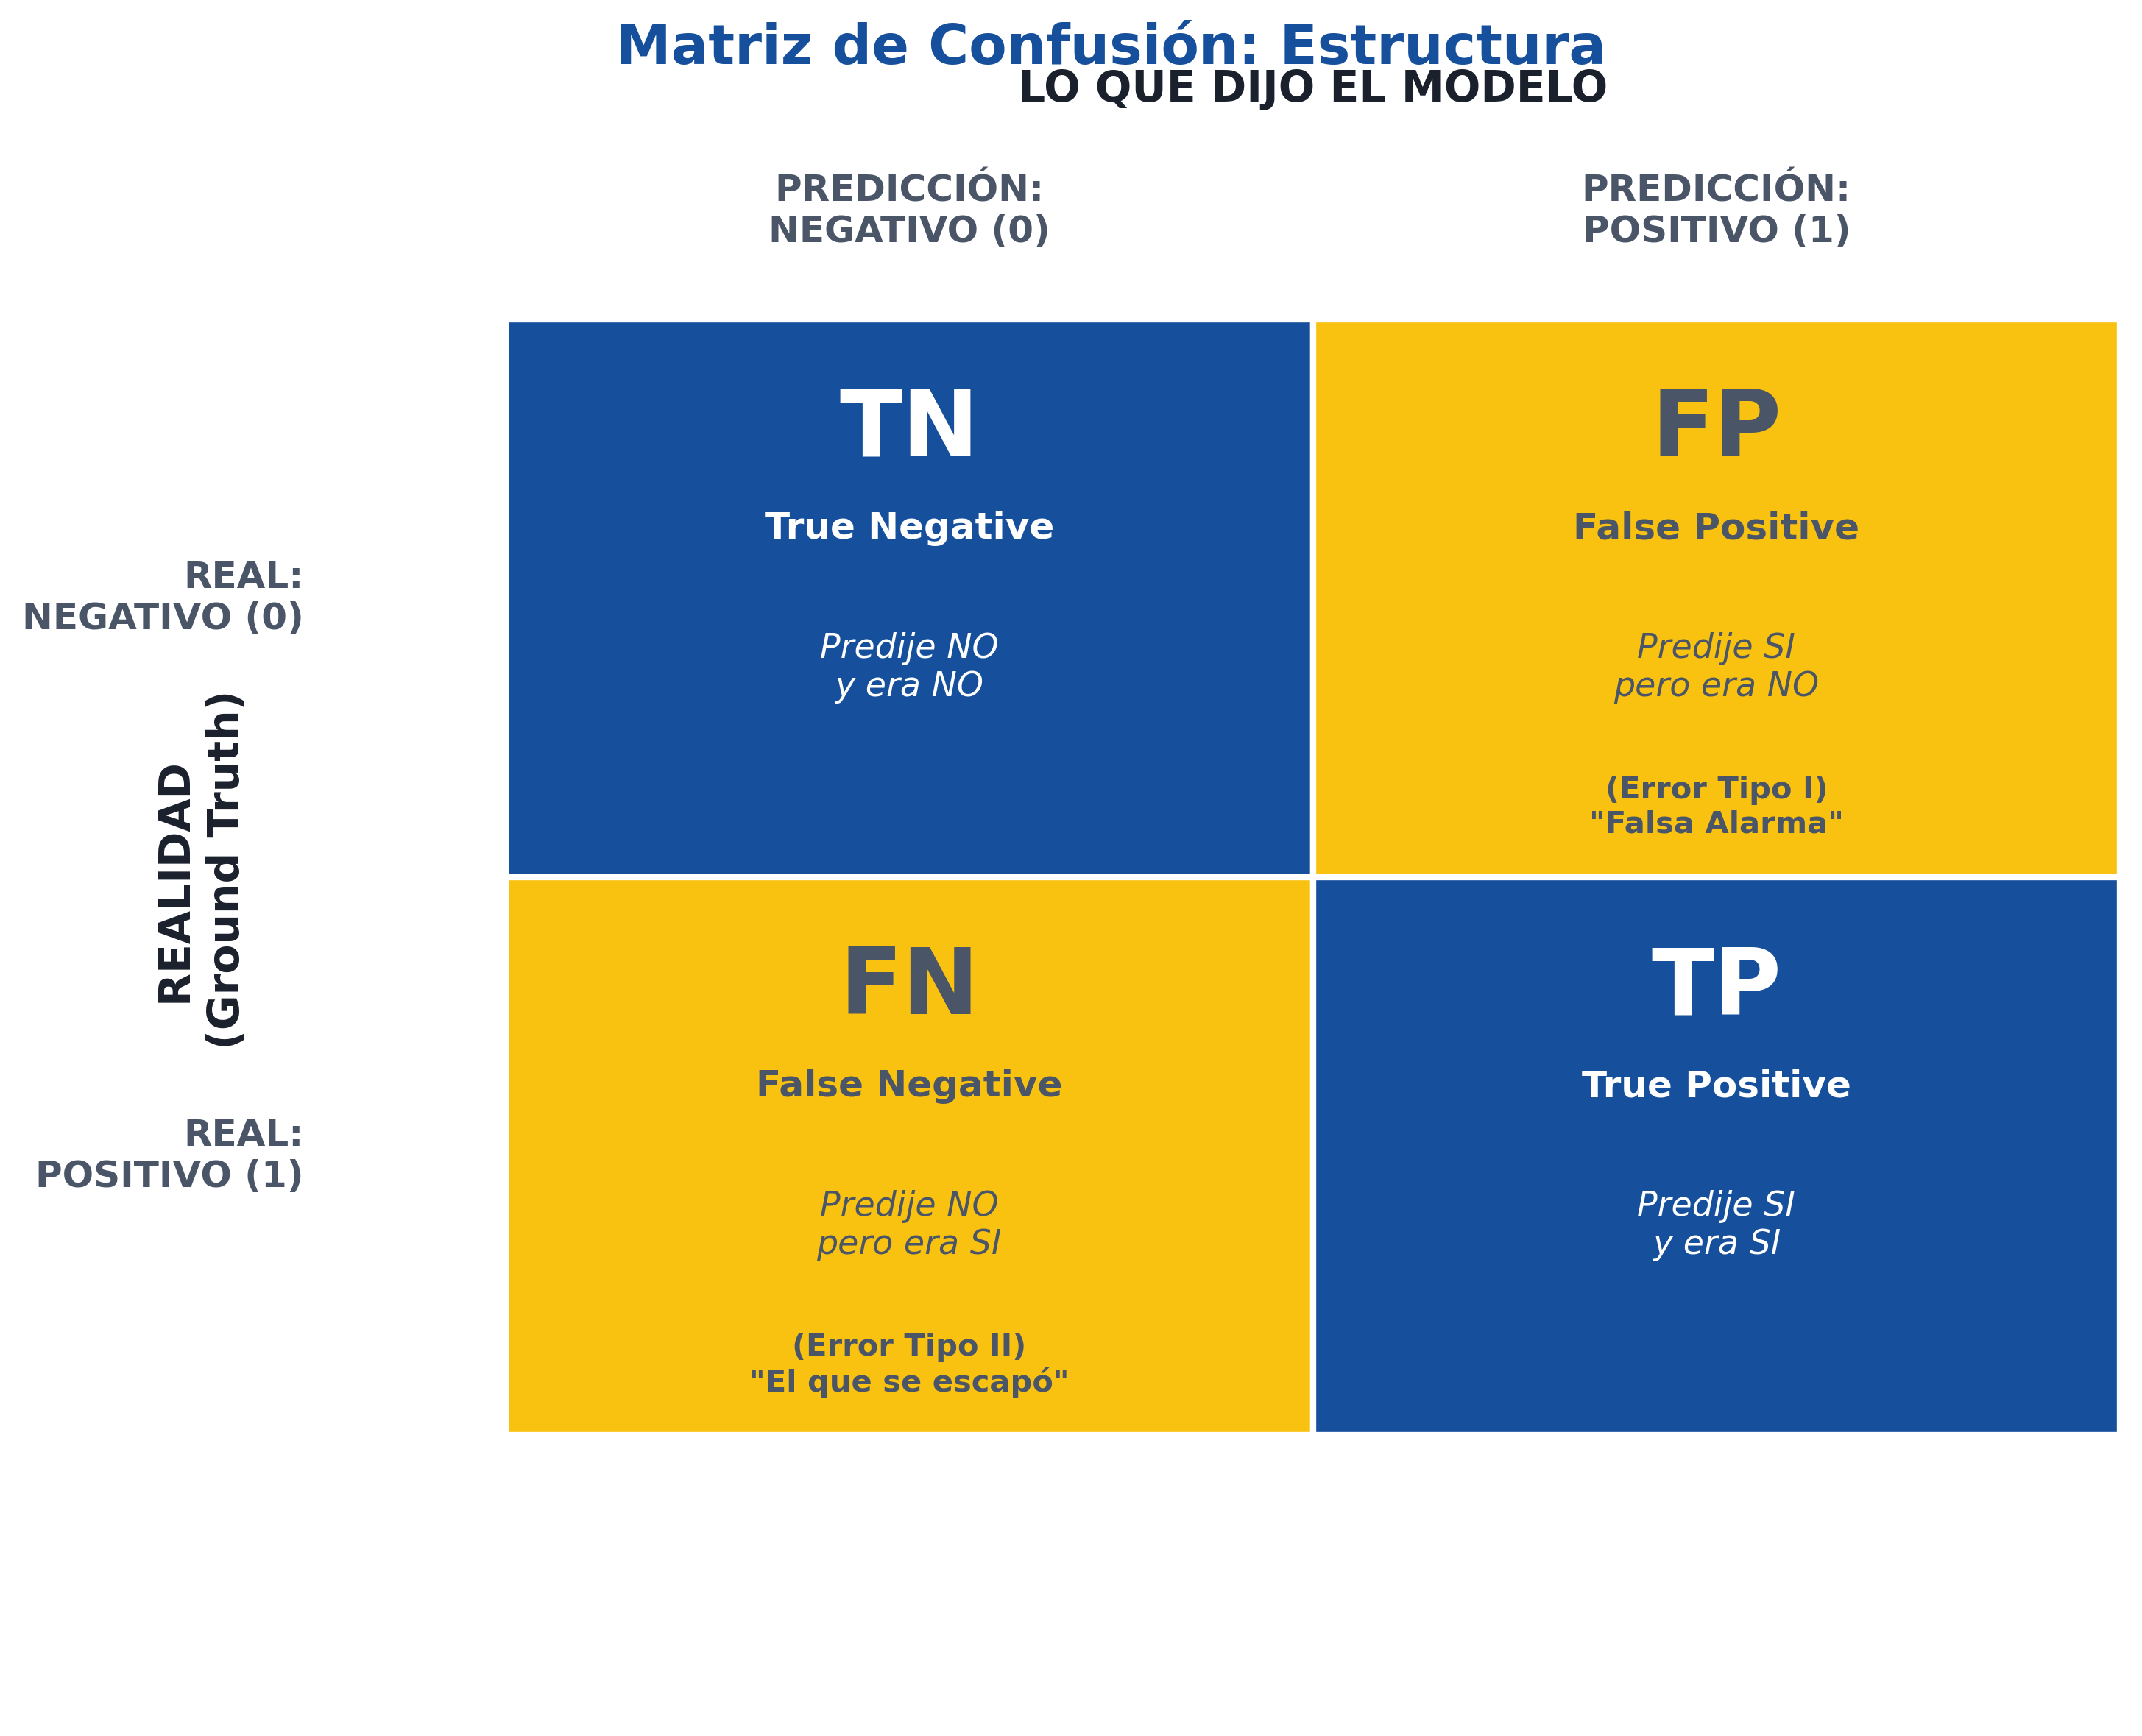
<figcaption aria-hidden="true">La matriz de confusión</figcaption>
</figure>

Cada celda de la matriz tiene un nombre propio:

| Nombre                    | Predicción | Realidad | Significado      |
|---------------------------|------------|----------|------------------|
| **TN** (*True Negative*)  | Negativo   | Negativo | Acierto negativo |
| **TP** (*True Positive*)  | Positivo   | Positivo | Acierto positivo |
| **FP** (*False Positive*) | Positivo   | Negativo | Falsa alarma     |
| **FN** (*False Negative*) | Negativo   | Positivo | Caso perdido     |

Tipos de resultado en clasificación binaria.

Con estos cuatro valores podemos definir las métricas con precisión:

| Métrica     | Fórmula         | Qué mide                                        | Úsala cuando…                  |
|----------------|----------------|-----------------|-------------------------|
| *Accuracy*  | (TP+TN) / Total | % predicciones correctas                        | Dataset balanceado             |
| *Precision* | TP / (TP+FP)    | De los que predije positivos, ¿cuántos lo eran? | FP es muy costoso (ej: spam)   |
| *Recall*    | TP / (TP+FN)    | De los positivos reales, ¿cuántos detecté?      | FN es muy costoso (ej: cáncer) |
| F1          | 2·P·R / (P+R)   | Balance entre precision y recall                | Dataset desbalanceado          |

Métricas de clasificación — guía de uso

Un modelo que siempre predice «sano» en un dataset con el 99 % de
muestras sanas tiene un 99 % de *accuracy* pero no detecta ningún caso
positivo. Esa es exactamente la situación en que *recall* es la métrica
relevante: lo que importa no es cuántas veces aciertas, sino cuántos
positivos reales detectas.

In [32]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

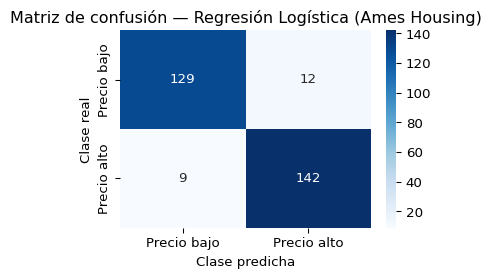

En lugar de calcular *Precision*, *Recall* y F1 por separado, usa
`classification_report` — imprime las cuatro métricas de un vistazo:

In [34]:
acc_log = accuracy_score(y_test_clf, y_pred_clf)
report  = classification_report(y_test_clf, y_pred_clf,
                                target_names=['Precio bajo', 'Precio alto'])

**Accuracy: 0.928**

| Clase       | Precision | Recall |    F1 | Support |
|:------------|----------:|-------:|------:|--------:|
| Precio bajo |     0.935 |  0.915 | 0.925 |     141 |
| Precio alto |     0.922 |   0.94 | 0.931 |     151 |

Métricas de clasificación — Regresión Logística (Ames Housing).

El modelo acierta en el **93%** de los casos. Para viviendas de precio
bajo, el Recall de 0.915 indica que detecta el 92% de las que realmente
lo son; para precio alto, el 94%. La Precision equilibrada entre clases
(0.935 vs 0.922) sugiere que el modelo no tiene sesgo sistemático hacia
ninguna de las dos. En un contexto real — por ejemplo, una tasadora que
no quiere infravalorar viviendas caras — el Recall de precio alto sería
la métrica crítica a maximizar.

**Reporta siempre las cuatro métricas, no solo *accuracy***

En proyectos reales, presenta *precision*, *recall* y F1 junto a la
*accuracy*. Los responsables de negocio necesitan entender el tipo de
error — una falsa alarma (FP) y un caso perdido (FN) tienen
consecuencias muy distintas según el problema.

Un clasificador de fraude bancario produce la siguiente matriz de
confusión: TP = 45, FP = 180, FN = 5, TN = 9.770.

1.  Calcula la *Accuracy* y el *Recall* manualmente. ¿Por qué la
    *Accuracy* puede resultar engañosamente alta en este caso?
2.  El equipo antifraude califica el modelo como «inútil» a pesar de un
    *Accuracy* cercano al 98 %. Explica su argumento usando los Falsos
    Positivos y los Falsos Negativos.
3.  En detección de fraude, ¿qué error tiene más coste de negocio: un
    Falso Positivo (bloquear una transacción legítima) o un Falso
    Negativo (dejar pasar fraude)? ¿Cambia la respuesta si el servicio
    es una tarjeta de débito versus una transferencia de gran importe?

### La curva ROC y AUC

Las métricas anteriores (*precision*, *recall*, F1) dependen de un
**umbral de decisión** — por defecto 0,5, pero ese valor es arbitrario.
En un problema de detección de fraude quizás prefieras bajar el umbral a
0,3 para no perder ningún caso sospechoso, aunque eso genere más falsas
alarmas. La curva ROC (*Receiver Operating Characteristic*) visualiza
cómo cambia el equilibrio entre aciertos y falsas alarmas al variar ese
umbral, y el **AUC** (*Area Under the Curve*) resume esa curva entera en
un único número: 1,0 es perfecto, 0,5 equivale a adivinar al azar, y por
encima de 0,8 se considera bueno en la mayoría de problemas.

Se calcula así:

In [36]:
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf[:, 1])
auc_log = roc_auc_score(y_test_clf, y_proba_clf[:, 1])

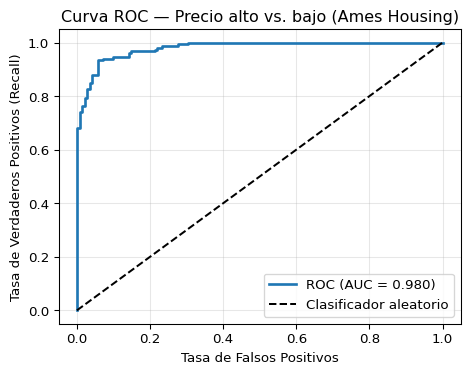

In [37]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Precio alto vs. bajo (Ames Housing)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva se aleja claramente de la diagonal (clasificador aleatorio) y
se acerca al vértice superior izquierdo — el punto ideal donde no hay
ningún falso positivo y se capturan todos los casos positivos. El AUC de
**0.980** indica una capacidad discriminativa excelente: el modelo
distingue correctamente entre viviendas de precio alto y precio bajo en
más de 98 de cada 100 comparaciones aleatorias entre un caso de cada
clase.

**Un AUC alto no siempre indica un problema interesante**

El AUC elevado de este modelo refleja que el barrio (`Neighborhood_enc`)
y la calidad de materiales (`OverallQual`) son predictores tan
correlacionados con el precio que la clasificación resulta casi
predecible. Cuando el problema tiene ese tipo de atajos, el modelo los
captura fácilmente — y el AUC sube.

Los problemas de clasificación más valiosos son los que no disponen de
ese predictor dominante. Por ejemplo: ¿puede detectarse si una vivienda
destaca en su barrio basándose *solo* en características estructurales
objetivas — superficie, antigüedad, garaje, sótano — sin conocer el
barrio ni la valoración subjetiva del tasador (`OverallQual` tiene r =
0,70 con el precio del barrio y puede reflejar ese sesgo de
localización)? Ese modelo tendría un AUC más modesto, pero respondería a
una pregunta genuinamente útil: encontrar viviendas bien construidas en
zonas asequibles, sin dejarse llevar por la etiqueta del barrio.

Dos modelos de detección de cáncer obtienen AUC = 0,92 y AUC = 0,89.

1.  ¿Significa esto que el primer modelo es siempre mejor en un
    hospital? ¿Qué factor adicional —más allá del AUC— debería
    considerar el oncólogo al elegir entre los dos?
2.  El médico quiere priorizar no dejar ningún tumor sin detectar,
    aunque eso genere más biopsias innecesarias. ¿Debería operar el
    modelo en un punto de la curva ROC con *Recall* alto o con
    *Precision* alta?
3.  Diseña un «modelo» que siempre prediga «cáncer». ¿Cuál sería su
    *Recall*? ¿Y su AUC? ¿Por qué no usaríamos ese clasificador en la
    práctica?

**Manos a la Obra**

### Clasificación y diagnóstico de errores

**Objetivo:** Implementar un flujo de clasificación binaria y evaluar el
rendimiento del modelo mediante el análisis crítico de métricas
contrapuestas.

**Contexto profesional:** Trabajas en una plataforma inmobiliaria de
Ames. El equipo de *marketing* quiere identificar viviendas con precio
por encima de la mediana del mercado para orientarles campañas premium.
Usarás el mismo *dataset* de UT5 y UT6.

**Instrucciones (Semi-guiado):**

1.  **Preparación:** Carga `house_prices_ml.csv`. Separa `X`
    (`GrLivArea`, `OverallQual`, `YearBuilt`, `GarageArea`,
    `BarrioPremium`) e `y` (`SalePrice`). Aplica *train/test split*
    (80/20, `random_state=42`) **antes** de calcular ningún umbral.
2.  **Target binario:** Calcula la mediana de `y_train` y úsala para
    crear las etiquetas: `y_train_clf = (y_train > mediana).astype(int)`
    y `y_test_clf = (y_test > mediana).astype(int)`. Aplicar la mediana
    de train al test evita filtrar información del test al modelo.
3.  **Entrenamiento:** Entrena un `LogisticRegression` con
    `StandardScaler` sobre `X_train` y `y_train_clf`.
4.  **Evaluación multimétrica:** Calcula el reporte completo (*Accuracy,
    Precision, Recall, F1*) y el AUC.
5.  **Visualización:** Genera la matriz de confusión y la curva ROC.
6.  **Análisis de negocio:** ¿Tu modelo comete más Falsos Positivos o
    Falsos Negativos? En este contexto concreto, ¿cuál de los dos
    errores tiene peor impacto para la plataforma inmobiliaria?
    Justifica.

**Criterio de éxito:** Con `random_state=42` y las 5 *features*
indicadas, deberías obtener una *Accuracy* ≈ 0,884 y un *AUC* ≈ 0,957.
El análisis final debe identificar claramente el *trade-off* entre
precisión y sensibilidad, y conectar con el contexto de negocio.

**Dificultad:** medio

In [40]:
# Escribe tu codigo aqui

## Árboles de Decisión: Modelos Interpretables No Lineales

La regresión lineal y la regresión logística son modelos potentes cuando
la relación entre las variables es aproximadamente lineal. Pero muchos
problemas reales no lo son: el precio de una vivienda no sube
indefinidamente con el tamaño, y el riesgo de impago no siempre depende
de una combinación lineal de ingresos y deudas. Para capturar relaciones
no lineales sin perder interpretabilidad existen otras familias de
algoritmos — los **árboles de decisión** son el ejemplo más intuitivo, y
la base sobre la que se construyen técnicas más potentes como Random
Forest.

### Intuición y Concepto

Un árbol de decisión estructura las predicciones como una secuencia de
preguntas anidadas: cada respuesta lleva a una nueva pregunta hasta
alcanzar una decisión final.

<figure>
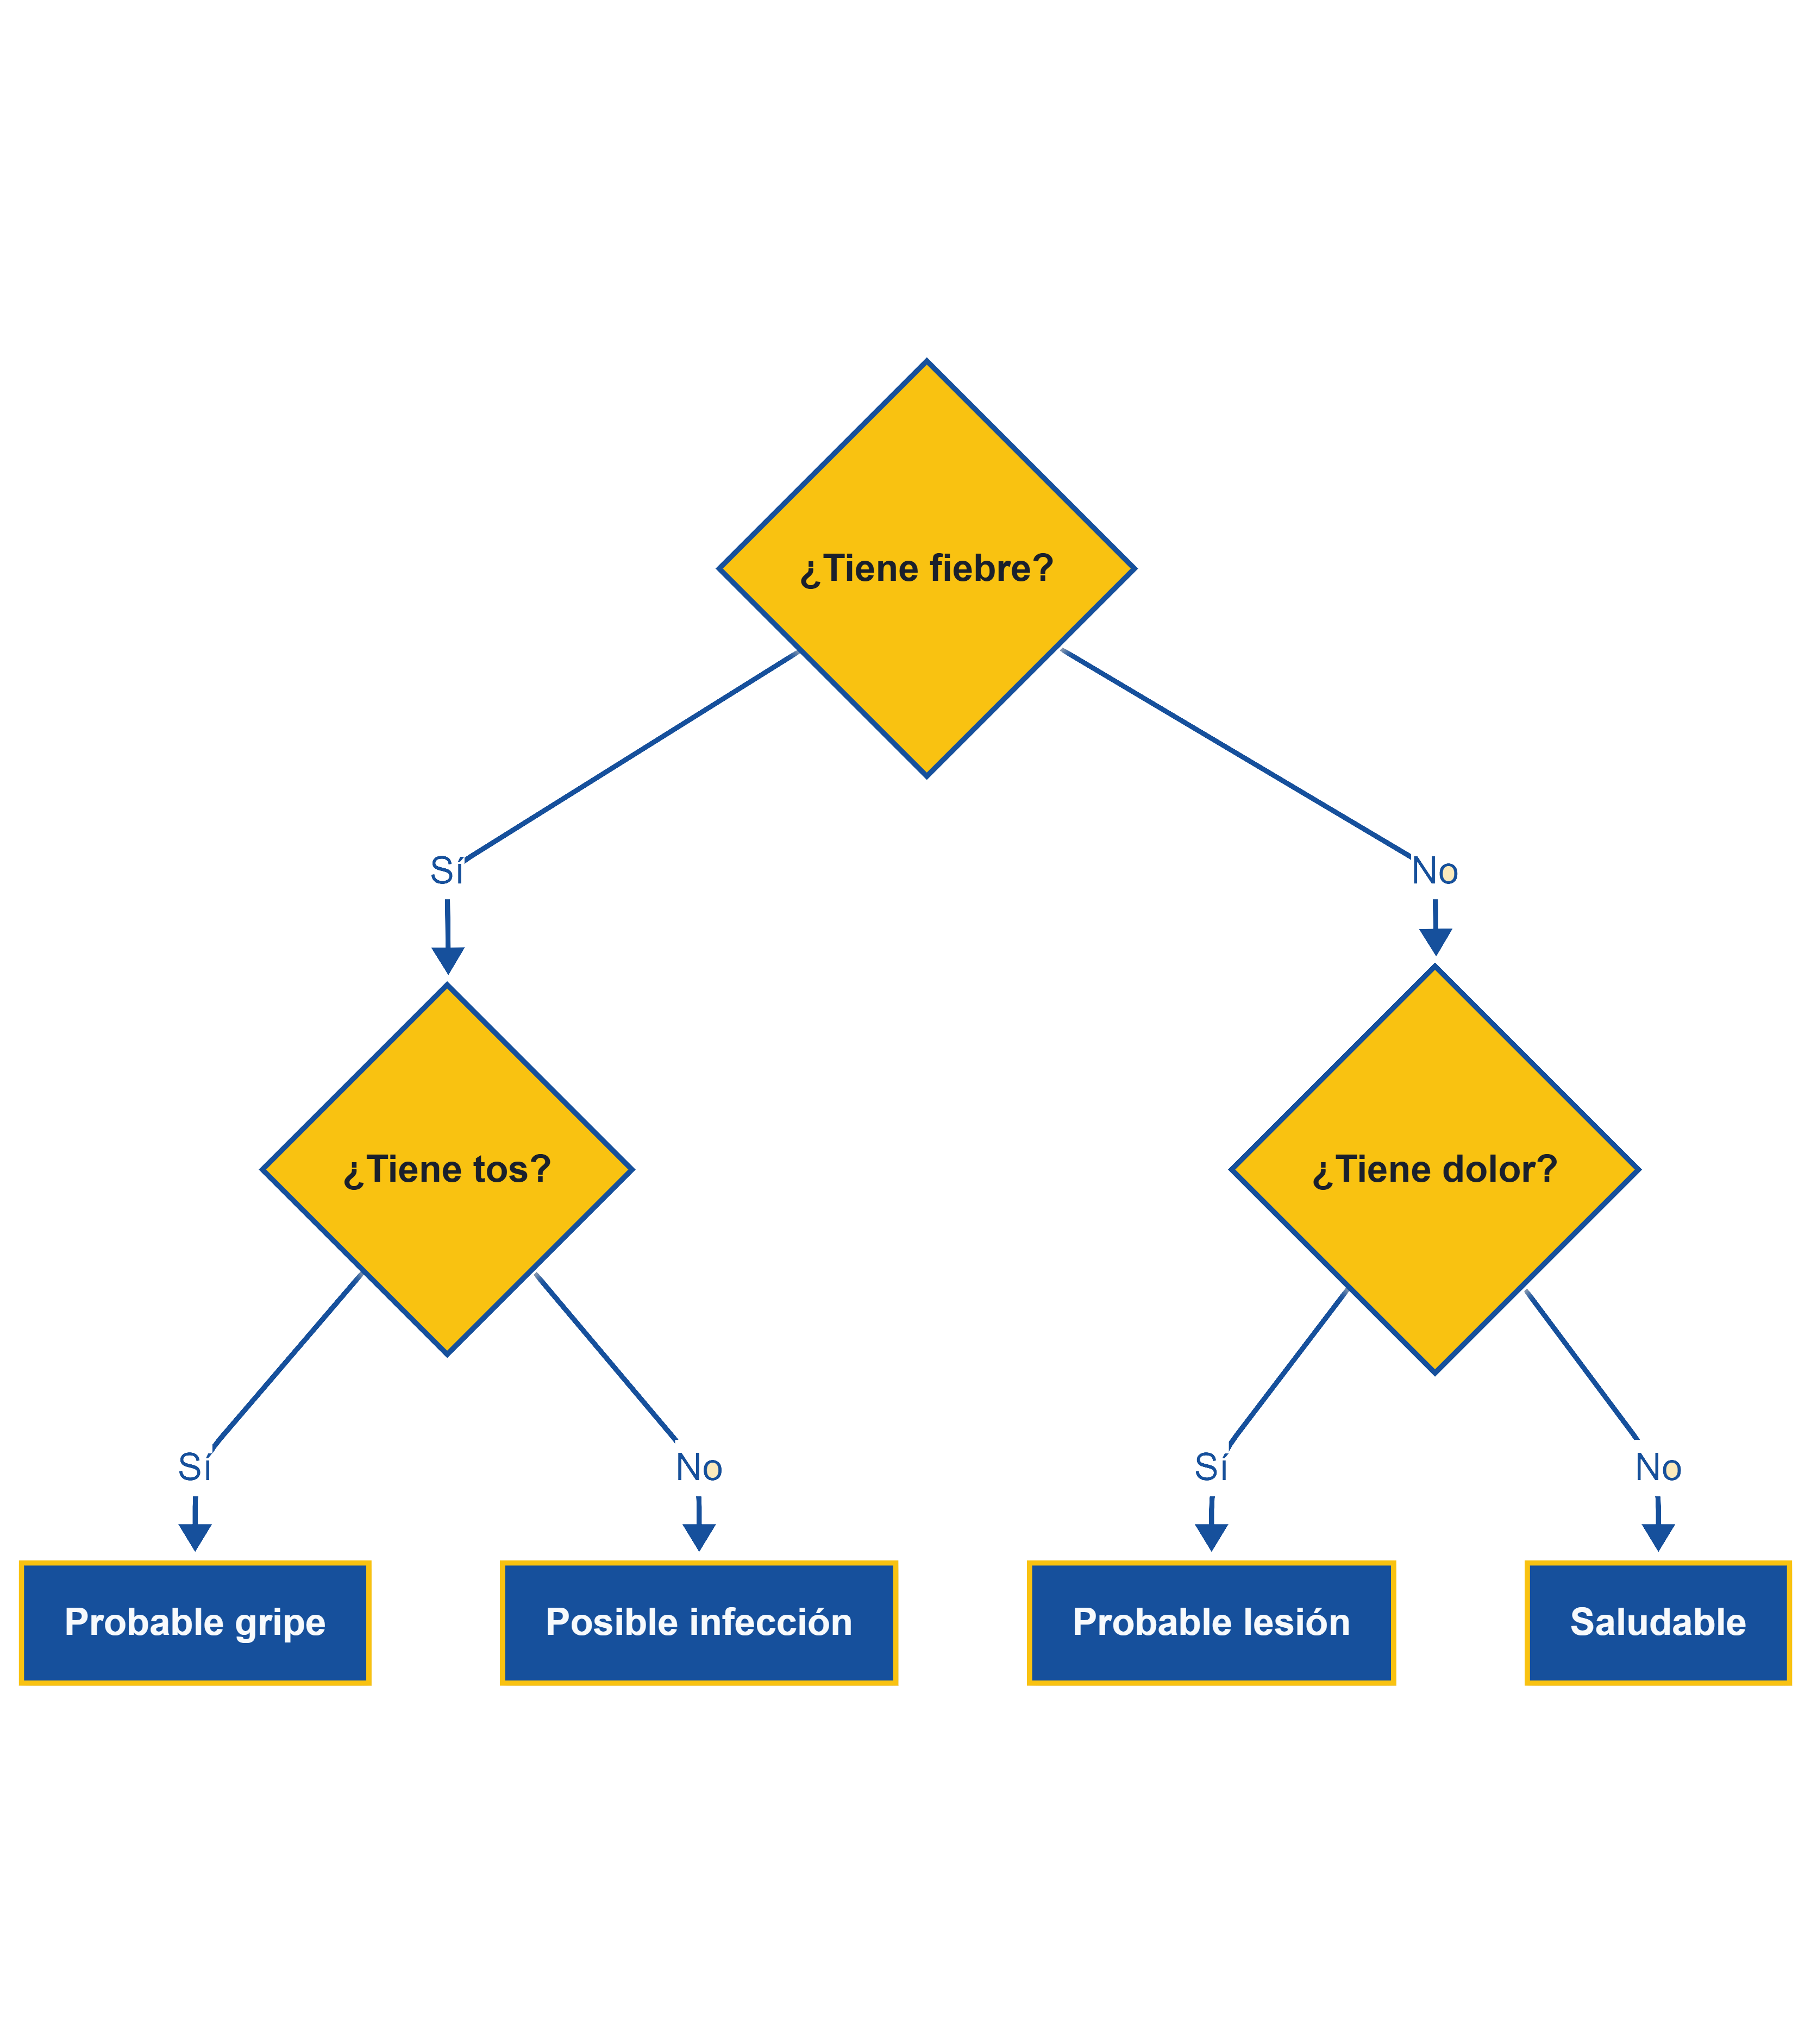
<figcaption aria-hidden="true">Arbol de decisión</figcaption>
</figure>

Cada pregunta recibe el nombre de **nodo**, cada respuesta posible es
una **rama**, y cada resultado final es una **hoja**.

| Ventajas                                               | Inconvenientes                                                                  |
|--------------------------|----------------------------------------------|
| Captura relaciones no lineales                         | Muy propenso a *overfitting* sin restricciones                                  |
| Detecta interacciones entre *features* automáticamente | Inestable: pequeños cambios en los datos pueden producir árboles muy diferentes |
| No requiere escalado                                   | Menor rendimiento que los métodos de *ensemble*                                 |
| Las reglas son directamente interpretables             | —                                                                               |

Ventajas e inconvenientes de los árboles de decisión frente a modelos
lineales

**En producción: Random Forest, no árboles individuales**

En producción es raro usar un único árbol de decisión — su tendencia al
sobreajuste lo hace poco fiable. Lo habitual es usar Random Forest, que
combina cientos de árboles para obtener predicciones más robustas. Por
eso entender cómo funciona un árbol individual es el paso previo
imprescindible para comprender los modelos de ensamble.

### Implementación en Scikit-learn

`DecisionTreeClassifier` sigue el mismo patrón de Scikit-learn, pero
introduce hiperparámetros de complejidad que controlan cuánto puede
aprender (y cuánto puede memorizar) el árbol:

In [41]:
from sklearn.tree import DecisionTreeClassifier

modelo_tree = DecisionTreeClassifier(
    max_depth=5,           # Profundidad máxima (anti-overfitting)
    min_samples_split=20,  # Mínimo de muestras para dividir nodo
    random_state=42
)
modelo_tree.fit(X_train, y_train_clf)    # X_train sin StandardScaler: los árboles dividen por umbrales,
y_pred_tree = modelo_tree.predict(X_test)  # no por sumas ponderadas — el escalado lineal no afecta los splits
importances_tree = modelo_tree.feature_importances_

Los parámetros del bloque anterior no son arbitrarios — cada uno limita
el crecimiento del árbol de una forma distinta. Los tres más relevantes
son:

| Parámetro           | *Default* | Recomendado | Efecto                                                        |
|-----------------|----------|-----------|----------------------------------|
| `max_depth`         | `None`    | 3–10        | Limita la profundidad; el más importante contra *overfitting* |
| `min_samples_split` | 2         | 10–50       | Mínimo de muestras para dividir un nodo                       |
| `min_samples_leaf`  | 1         | 5–20        | Mínimo de muestras en cada hoja                               |

Hiperparámetros de `DecisionTreeClassifier` — los tres *defaults*
producen *overfitting* severo

**Error común: usar los *defaults* de *Decision Tree***

Evita usar los *defaults* de *Decision Tree* sin ajustar. Sin
restricciones (`max_depth=None`, `min_samples_split=2`), el árbol
crecerá hasta memorizar completamente los datos de entrenamiento,
produciendo *overfitting* severo. Siempre establece al menos `max_depth`
y `min_samples_split`.

### Visualización del árbol

Una vez entrenado, la mayor ventaja del árbol frente a cualquier otro
algoritmo de esta unidad es que sus reglas son directamente legibles.
`plot_tree()` genera una representación visual de todas las decisiones
del árbol — la característica que hace a este algoritmo más explicable
que cualquier otro de esta unidad:

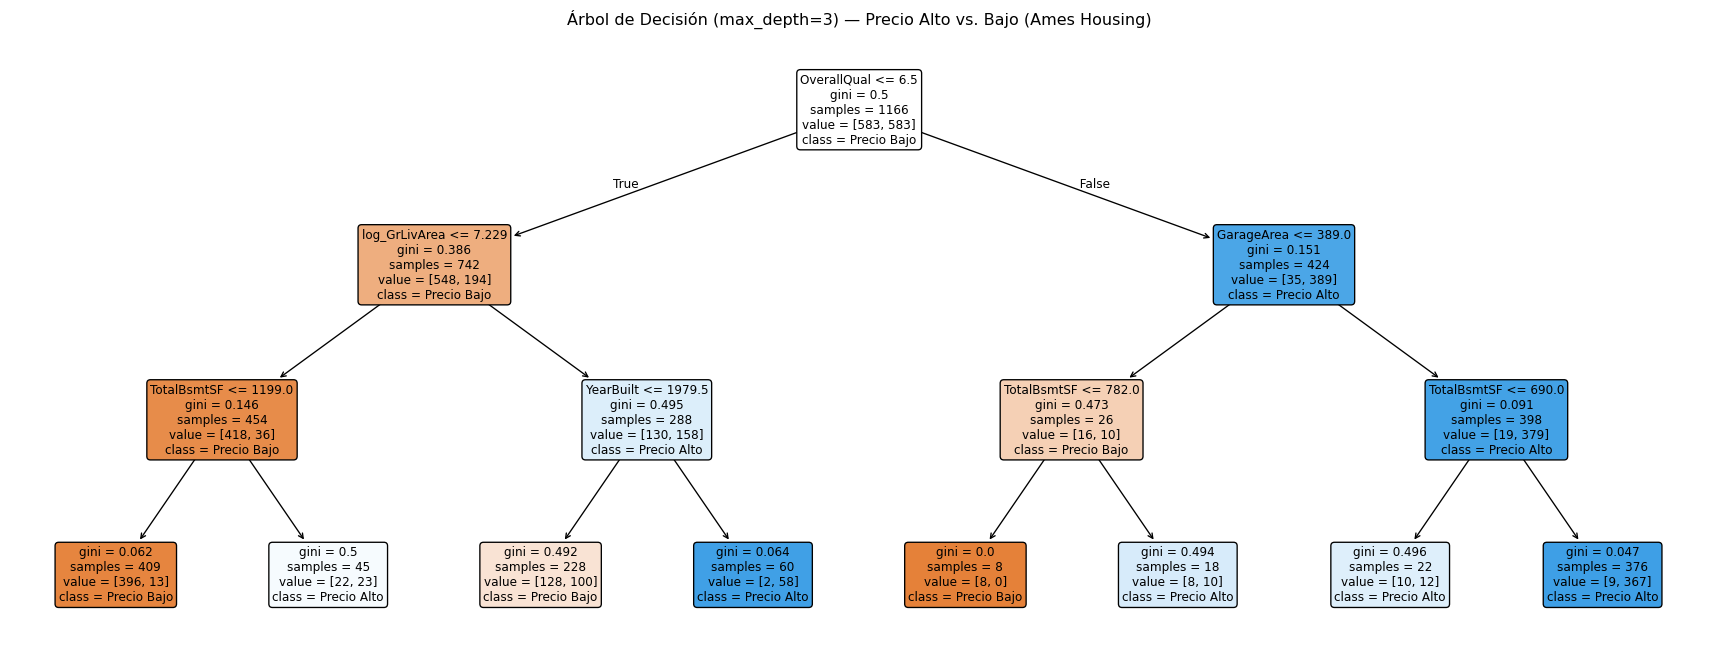

In [42]:
from sklearn.tree import plot_tree

# Para visualización usamos max_depth=3 con las features del modelo —
# los umbrales son directamente interpretables (OverallQual <= 6.5, YearBuilt <= 1984).
# log_GrLivArea <= 7.3 equivale aproximadamente a 1.480 ft² de superficie habitable.
# Con max_depth=5 el árbol sería ilegible en pantalla.
_feats_viz = ['OverallQual', 'log_GrLivArea', 'YearBuilt', 'GarageArea', 'TotalBsmtSF']
_tree_viz = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
_tree_viz.fit(X_train_raw[_feats_viz].fillna(0), y_train_clf)

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(_tree_viz,
          feature_names=_feats_viz,
          class_names=['Precio Bajo', 'Precio Alto'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=3) — Precio Alto vs. Bajo (Ames Housing)')
plt.tight_layout()
plt.show()

Cada nodo del árbol muestra la información necesaria para entender la
decisión tomada en ese punto. Tomemos como ejemplo el nodo raíz, que
divide el dataset completo:

    OverallQual <= 6.5
    gini = 0.50
    samples = 1166
    value = [0, 0]
    class = Precio Bajo

-   **`OverallQual <= 6.5`** — la regla de decisión: las viviendas con
    `OverallQual` por debajo del umbral van a la rama izquierda. El
    umbral está en la unidad original, directamente interpretable.
-   **`gini = 0.50`** — mide la mezcla de clases en ese nodo. Vale 0
    cuando todas las observaciones son de la misma clase (nodo puro) y
    0,5 cuando las clases están al 50/50 — como aquí, donde el modelo
    aún no ha separado nada.
-   **`samples = 1166`** — número de viviendas que llegan a este nodo.
-   **`value = [0, 0]`** — cuántas son de precio bajo (0) y de precio
    alto (0).
-   **`class = Precio Bajo`** — si el árbol se detuviera aquí,
    prediciría la clase mayoritaria.

A medida que el árbol profundiza, los nodos se vuelven más puros (gini
más cercano a 0) y el color más intenso. Un camino completo raíz → hoja
se lee como una regla de negocio directa — las reglas exactas se leen en
la gráfica anterior, donde cada nodo muestra la condición, la pureza y
el número de viviendas afectadas.

Esta trazabilidad es la mayor ventaja del árbol frente a otros
algoritmos: las reglas de decisión se pueden mostrar directamente a un
cliente o a un responsable de negocio sin necesidad de explicar ningún
concepto estadístico.

### *Feature importance*

La visualización muestra las reglas; el *feature importance* responde a
una pregunta complementaria: ¿qué variables influyen más en esas reglas?
La importancia de cada *feature* se calcula en función de cuánto reduce
la impureza (medida con el índice Gini o la entropía) en todos los nodos
donde se utiliza. Una *feature* que aparece en los primeros niveles del
árbol (cerca de la raíz) generalmente tiene mayor importancia, ya que
divide un número mayor de muestras. Esto nos da una respuesta basada en
datos a la pregunta “¿qué factores importan más para esta predicción?”.

In [45]:
_fimp = (pd.DataFrame({'feature': _feats_viz,
                       'importance': _tree_viz.feature_importances_})
           .sort_values('importance', ascending=False))

La suma de todas las importancias es siempre 1,0. Una importancia de 0,5
significa que esa *feature* contribuye al 50 % de las decisiones del
modelo. Comparar el *feature importance* entre modelos diferentes ayuda
a validar la consistencia: si un modelo declara crítica la *feature* A y
otro la trata como irrelevante, merece investigación.

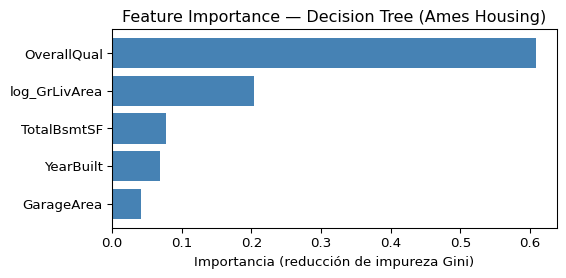

`OverallQual` lidera con una importancia de **0.61** — es la variable
que más reduce la impureza Gini en el árbol, y aparece en los primeros
niveles donde se divide la mayor parte del dataset. Este resultado es
coherente con la correlación r = 0,79 detectada en el EDA de UT6.

**¿Es `OverallQual` un predictor objetivo?**

Antes de aceptar este resultado sin más, conviene recordar que
`OverallQual` es la valoración global de un tasador — no una medida
física directa. Como se mostró en el EDA, está correlacionada con el
precio del barrio (r ≈ 0,70) y con otras variables de calidad como
`ExterQual` o `KitchenQual`: puede que el árbol no haya encontrado el
mejor predictor estructural, sino el mejor resumen de múltiples señales
mezcladas con el sesgo de localización. Un experimento esclarecedor:
entrenar el mismo modelo *sin* `OverallQual` y observar cuánto caen las
métricas y qué variables ascienden para compensar.

La suma de los `feature_importances_` de un árbol de decisión siempre es
1,0.

1.  ¿Qué mide exactamente `feature_importances_` en un árbol? ¿Es lo
    mismo que la correlación de Pearson calculada en el EDA? Justifica
    por qué pueden dar resultados distintos.
2.  Si añades al modelo `GarageArea` y `GarageCars` simultáneamente
    (correlación r = 0,89 entre ellas), ¿qué efecto podría tener eso
    sobre la importancia calculada de cada una por separado?
3.  ¿Puede una variable tener `feature_importance` exactamente igual a 0
    en un árbol entrenado? ¿Qué significaría eso sobre su utilidad para
    el modelo?

### Diagnóstico de *overfitting*

Sin restricciones, un árbol crece hasta memorizar completamente los
datos de entrenamiento. El siguiente diagnóstico cuantifica la brecha
comparando la exactitud en train y en test:

In [48]:
train_score = modelo_tree.score(X_train, y_train_clf)
test_score  = modelo_tree.score(X_test,  y_test_clf)
gap = train_score - test_score

-   **Train score:** 0.928  
-   **Test score:** 0.921  
-   **Diferencia:** 0.007 → *overfitting* ligero (aceptable)

La diferencia entre train y test es la señal más directa de sobreajuste.

Las soluciones van de más simple a más sofisticada:

1.  Reducir `max_depth`.
2.  Aumentar `min_samples_split` o `min_samples_leaf`.
3.  Aplicar *pruning* (poda) postentrenamiento.
4.  Usar *Random Forest* (múltiples árboles independientes).

**Manos a la Obra**

### árboles de decisión con diagnóstico de *overfitting*

**Objetivo:** entrenar árboles con diferentes configuraciones y
diagnosticar *overfitting*.

**Dataset:** usa Ames Housing (`house_prices_ml.csv`) con la misma
clasificación binaria de precio alto/bajo trabajada en esta unidad.

1.  **Parte A (sin restricciones):** entrena `DecisionTreeClassifier`
    con *defaults* (sin `max_depth`, etc.). Evalúa `train_score` y
    `test_score`. ¿Hay *overfitting*? Calcula la diferencia.
2.  **Parte B (con restricciones):** entrena con `max_depth=3`,
    `min_samples_split=50`. Evalúa `train_score` y `test_score`. Compara
    con la Parte A.
3.  **Parte C (visualización):** visualiza el árbol restringido (Parte
    B). Identifica la *feature* más importante. Traduce una rama del
    árbol a lenguaje natural.
4.  ¿Cuál árbol tiene mejor `test_score`? ¿Por qué?
5.  ¿El árbol sin restricciones memorizó los datos de *train*?
6.  ¿Las reglas del árbol restringido tienen sentido
    narrativo/intuitivo?
7.  Si tuvieras que explicar el modelo a un gerente no técnico, ¿qué
    árbol usarías?
8.  **Interpretación de negocio:** En una celda Markdown escribe 2-3
    frases respondiendo: el árbol restringido clasifica mal el ~13,7% de
    las viviendas. Para una empresa que compra y vende propiedades, ¿qué
    consecuencia concreta tiene ese error? ¿Prefierirías reducir los
    Falsos Positivos (clasificar como “precio alto” una vivienda barata)
    o los Falsos Negativos (clasificar como “precio bajo” una vivienda
    cara)? ¿Por qué?

**Criterio de éxito:** Con `random_state=42` y las 5 *features* de P8.2
(`GrLivArea`, `OverallQual`, `YearBuilt`, `GarageArea`,
`BarrioPremium`), deberías obtener: árbol sin restricciones — *train
accuracy* ≈ 1,00, *test accuracy* ≈ 0,853 (brecha ≈ 0,146, *overfitting*
severo); árbol con `max_depth=3, min_samples_split=50` — *train
accuracy* ≈ 0,895, *test accuracy* ≈ 0,863 (brecha ≈ 0,032, ajuste
saludable). La variable con mayor importancia en el árbol restringido es
`YearBuilt`. La interpretación de negocio debe razonar en términos de
coste real para la empresa, no solo citar el porcentaje de error.

Los árboles de decisión crecen sin límite por defecto. Consulta los
hiperparámetros de poda en el **Apéndice C.7**.

**Dificultad:** medio

In [50]:
# Escribe tu codigo aqui

## *Random Forest*: el poder de la sabiduría colectiva

Un árbol de decisión tiene un límite natural: más profundidad mejora el
ajuste sobre los datos de entrenamiento, pero empeora la generalización.
¿Cómo superar ese límite sin abandonar la lógica de los árboles?

La respuesta es aplicar una estrategia general del ML llamada
***ensemble learning***: en lugar de construir un modelo más complejo,
construimos **muchos modelos más simples con variaciones internas** y
combinamos sus predicciones. La idea es que los errores individuales de
cada modelo son aleatorios y se cancelan entre sí, mientras que los
patrones reales se refuerzan. *Random Forest* es la implementación más
exitosa de esta idea aplicada a los árboles de decisión.

### Intuición: *ensemble learning*

El árbol de decisión es interpretable pero frágil: un pequeño cambio en
los datos puede producir un árbol completamente diferente. *Random
Forest* soluciona esto entrenando 100 árboles distintos y dejando que
“voten” — como un jurado en lugar de un solo juez. Aunque algún árbol se
equivoque, la mayoría compensa. Eso es *ensemble learning*.

El mecanismo interno en cuatro pasos:

1.  Crea 100 árboles de decisión (*default*: `n_estimators=100`).
2.  Cada árbol se entrena con una muestra aleatoria con reposición
    (*bootstrap sampling*).
3.  Cada árbol considera solo un subconjunto aleatorio de *features* en
    cada *split*.
4.  Predicción final = voto mayoritario (clasificación) o promedio
    (regresión).

| Ventajas frente a un solo árbol                                              | Inconvenientes                                                      |
|------------------------------------------------|-------------------------|
| Mucho menos *overfitting* (los errores de árboles individuales se compensan) | No es directamente interpretable (no puedes visualizar 100 árboles) |
| Más robusto ante *outliers* y ruido                                          | Más lento de entrenar y predecir                                    |
| Mejor rendimiento en casi todos los problemas tabulares                      | Mayor consumo de memoria                                            |
| *Feature importance* más estable al promediar sobre 100 árboles              | —                                                                   |

*Random Forest* vs. árbol de decisión individual

1.  Un árbol de decisión entrenado sin restricciones obtiene *train
    accuracy* = 1,00 y *test accuracy* = 0,72. Un *Random Forest* con
    los mismos datos obtiene *train accuracy* = 0,94 y *test accuracy* =
    0,88. ¿Qué fenómeno ilustra el árbol sin restricciones? ¿Por qué el
    *Random Forest* generaliza mejor?
2.  Si tienes 100 árboles en el *Random Forest*, ¿necesitas que cada
    árbol sea perfecto individualmente para que el conjunto sea bueno?
    ¿Qué propiedad estadística lo justifica?
3.  ¿En qué situación preferirías un único árbol de decisión sobre un
    *Random Forest*, aunque el *Random Forest* sea más preciso?

### Implementación en Scikit-learn

La API sigue el mismo patrón `fit`/`predict`/`score`. Los dos parámetros
nuevos más relevantes son `n_estimators` (número de árboles) y
`n_jobs=-1` (paralelización en todos los núcleos de la CPU, que reduce
drásticamente el tiempo de entrenamiento):

In [51]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,   # Número de árboles
    max_depth=10,       # Profundidad de cada árbol
    random_state=42,
    n_jobs=-1           # Usa todos los cores del CPU
)
modelo_rf.fit(X_train, y_train_clf)
y_pred_rf    = modelo_rf.predict(X_test)
y_proba_rf   = modelo_rf.predict_proba(X_test)[:, 1]

**Hiperparámetros clave:**

| Parámetro      | *Default* | Recomendado | Efecto                                         |
|-------------------|-------------------|----------------------|--------------|
| `n_estimators` | 100       | 100–500     | Más árboles = más robusto (pero más lento)     |
| `max_depth`    | `None`    | 10–30       | Profundidad de cada árbol individual           |
| `n_jobs`       | 1         | `-1`        | Usa todos los núcleos de la CPU; siempre ponlo |

Hiperparámetros principales de `RandomForestClassifier`

### *Feature importance* robusto

¿Recuerdas que en la sección anterior calculamos la importancia de
*features* con un solo árbol? El problema es que un único árbol es muy
sensible a los datos concretos que recibe: cambia ligeramente el
*dataset* y la importancia de las *features* puede variar drásticamente.
*Random Forest* resuelve esto promediando la importancia sobre 100
árboles diferentes, cada uno entrenado con una muestra distinta. El
resultado es una estimación mucho más estable y fiable de qué variables
realmente importan.

El código es idéntico al del árbol individual; la diferencia es que
ahora `feature_importances_` es el promedio sobre los 100 árboles, no
sobre uno solo:

In [52]:
_fimp_rf = (pd.DataFrame({'feature': X_train.columns,
                           'importance': modelo_rf.feature_importances_})
              .sort_values('importance', ascending=False))

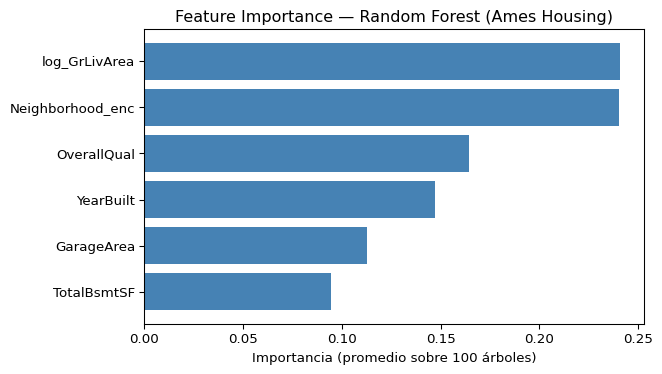

`log_GrLivArea` lidera con **0.24** de importancia, seguido de
`Neighborhood_enc` (0.24). Al promediar sobre 100 árboles entrenados con
muestras distintas, este ranking es mucho más estable que el del árbol
individual — confirma el hallazgo del EDA de UT6 y no depende de un
único split aleatorio. Aun así, conviene aplicar el mismo escepticismo
señalado en la sección de árboles: `OverallQual` es una valoración
subjetiva con r ≈ 0,70 respecto al precio del barrio, por lo que su
liderazgo puede reflejar en parte un sesgo de localización.

Un árbol de decisión individual identifica `GarageArea` como la segunda
variable más importante. Un *Random Forest* de 100 árboles la sitúa en
quinta posición.

1.  ¿Por qué puede haber tanta diferencia? ¿Cuál de las dos estimaciones
    confiarías más para presentar a un cliente y por qué?
2.  El *Random Forest* promedia la importancia sobre 100 árboles, cada
    uno entrenado con una muestra distinta. ¿Cómo sabes que 100 árboles
    son suficientes? ¿Qué ocurriría con `n_estimators=5`?
3.  La suma de todas las `feature_importances_` del *Random Forest*
    también es exactamente 1,0. Si tienes 6 variables y `OverallQual`
    concentra el 50 % de la importancia, ¿cuánto puede sumar el resto de
    variables como máximo? ¿Qué implicaría eso para un modelo que
    excluyera `OverallQual`?

En la industria, *Random Forest* es a menudo la primera opción después
de probar regresión lineal/logística. Es el “caballo de batalla” del ML
tradicional: funciona razonablemente bien en la mayoría de problemas
tabulares sin necesidad de mucho ajuste. Muchos equipos de datos lo usan
como *baseline* robusto antes de explorar modelos más complejos como
*Gradient Boosting* (XGBoost, LightGBM).

### Comparación de modelos

En un proyecto profesional de ML, nunca te quedas con el primer modelo
que entrenas. La práctica estándar es entrenar varios candidatos y
compararlos de forma sistemática usando las mismas métricas y los mismos
datos de *test*. Esta comparación objetiva es lo que te permite
justificar ante un cliente o un responsable técnico por qué elegiste un
modelo sobre otro.

**Tabla comparativa:**

Los tres modelos ya están entrenados sobre los mismos datos
(`X_train`/`X_test`, `y_train_clf`/`y_test_clf`). La comparación es
directa:

In [55]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

_modelos_cmp = {
    'Regresión Logística': (modelo_log,  y_pred_clf,  y_proba_clf[:, 1]),
    'Árbol de Decisión':   (modelo_tree, y_pred_tree, modelo_tree.predict_proba(X_test)[:, 1]),
    'Random Forest':       (modelo_rf,   y_pred_rf,   y_proba_rf),
}
_rows_cmp = [
    {'Modelo':   nombre,
     'Accuracy': round(accuracy_score(y_test_clf, yp), 3),
     'F1':       round(f1_score(y_test_clf, yp), 3),
     'AUC':      round(roc_auc_score(y_test_clf, yprob), 3)}
    for nombre, (_, yp, yprob) in _modelos_cmp.items()
]
_comp_cmp = pd.DataFrame(_rows_cmp).set_index('Modelo')

| Modelo              | Accuracy |    F1 |   AUC |
|:--------------------|---------:|------:|------:|
| Regresión Logística |    0.928 | 0.931 |  0.98 |
| Árbol de Decisión   |    0.921 | 0.926 | 0.956 |
| Random Forest       |    0.928 | 0.931 | 0.972 |

Comparación de modelos de clasificación sobre Ames Housing (mismo
*split* 80/20).

Los tres modelos superan el *baseline* aleatorio (AUC \> 0,5).
**Regresión Logística** lidera en AUC con 0.98, pero la diferencia
respecto al último es de solo 0.024 puntos de AUC y 0.007 de *accuracy*
— un margen muy reducido que ilustra que en problemas reales **la
calidad de los datos importa más que el algoritmo elegido**: los datos
de Ames Housing ya venían limpios gracias a UT5 y enriquecidos por el
EDA de UT6.

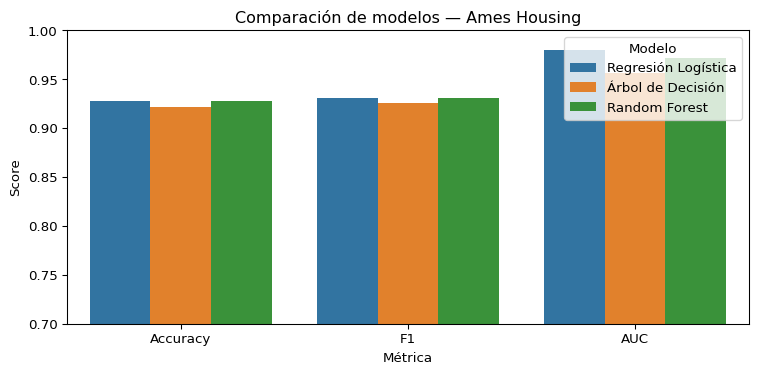

In [58]:
import seaborn as sns

_comp_long = _comp_cmp.reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=_comp_long, x='Métrica', y='Valor', hue='Modelo', ax=ax)
ax.set_title('Comparación de modelos — Ames Housing')
ax.set_ylabel('Score')
ax.legend(title='Modelo')
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

La métrica más alta no siempre señala el mejor modelo para producción.
Considera:

-   **Interpretabilidad:** si necesitas explicar las decisiones →
    regresión lineal o árbol.
-   **Velocidad de inferencia:** si las predicciones deben ser en tiempo
    real → modelos lineales.
-   **Rendimiento puro:** si solo importa la precisión → *Random Forest*
    suele ganar.
-   **Mantenimiento:** los modelos complejos requieren más experiencia
    para depurar y actualizar.

**Manos a la Obra**

### Comparación sistemática y selección de modelos

**Objetivo:** Entrenar múltiples algoritmos y realizar una comparativa
técnica rigurosa para decidir qué modelo es el más adecuado para
producción.

**Contexto profesional:** Debes presentar una propuesta técnica al
director de tecnología (CTO). No solo importa el acierto, sino también
la complejidad y la interpretabilidad del modelo.

**Tu Misión (Autónomo):**

1.  Usa Ames Housing (`house_prices_ml.csv`) con la clasificación de
    precio alto vs. bajo trabajada en esta unidad.
2.  Entrena tres modelos diferentes: un baseline simple (Regresión
    Lineal o Logística), un Árbol de Decisión y un Random Forest.
3.  Genera una tabla comparativa que resuma al menos 3 métricas de
    rendimiento para cada modelo (p. ej. *Accuracy*, *F1* y *AUC*).
4.  **Visualización de mérito:** Crea un gráfico de barras comparativo
    que permita ver las diferencias de rendimiento de un vistazo.
5.  **Justificación profesional:** Redacta una breve conclusión
    respondiendo: ¿Cuál de los tres modelos desplegarías en producción?
    No elijas automáticamente el que tenga mejor métrica; considera el
    equilibrio entre precisión, riesgo de sobreajuste y facilidad de
    explicación a un cliente.

**Criterio de éxito:** Con `random_state=42`, las 5 *features*
(`GrLivArea`, `OverallQual`, `YearBuilt`, `GarageArea`, `BarrioPremium`)
y la clasificación precio alto/bajo (`SalePrice > mediana`), deberías
obtener: Regresión Logística — Accuracy = 0,884, F1 = 0,880, AUC =
0,957; Árbol de Decisión (depth=5) — Accuracy = 0,856, F1 = 0,848, AUC =
0,938; Random Forest — Accuracy = 0,877, F1 = 0,873, AUC = 0,959.
Observa que el Random Forest tiene el AUC más alto pero no el mejor
Accuracy. La justificación profesional debe argumentar la elección
considerando al menos dos factores (ej: precisión vs. interpretabilidad,
o rendimiento vs. tiempo de inferencia).

**Dificultad:** avanzado

In [59]:
# Escribe tu codigo aqui

### Síntesis: cuatro modelos para dos tareas

Tienes ahora cuatro herramientas para abordar cualquier problema de
aprendizaje supervisado:

| Algoritmo           | Tarea                     | Fortaleza principal           | Limitación                          |
|----------------|-----------|-----------------------------|-----------------|
| Regresión lineal    | Regresión                 | Coeficientes interpretables   | Solo relaciones lineales            |
| Regresión logística | Clasificación             | Probabilidades calibradas     | Solo fronteras lineales             |
| Árbol de decisión   | Regresión y clasificación | Reglas explicables, no lineal | *Overfitting* sin restricciones     |
| *Random Forest*     | Regresión y clasificación | Robusto y preciso             | Difícil de interpretar directamente |

Guía de selección de algoritmo — aprendizaje supervisado básico

Un banco quiere predecir si un cliente impagará un préstamo. El
*dataset* tiene 200.000 clientes y 45 *features* (historial de pagos,
nivel de ingresos, tipo de contrato, etc.).

1.  ¿Qué tipo de problema es — clasificación o regresión? Justifica.
2.  El responsable de riesgo exige que el modelo sea explicable:
    “necesito saber por qué rechazamos a este cliente concreto”. ¿Qué
    algoritmo de la tabla descartarías por esto? ¿Cuál favorecería este
    requisito?
3.  La variable objetivo está muy desbalanceada: 95 % no impaga, 5 % sí
    impaga. ¿Cambia tu elección de algoritmo? ¿Qué parámetro de
    `train_test_split` deberías usar?

El proceso completo se ilustra en el siguiente diagrama:

<figure>
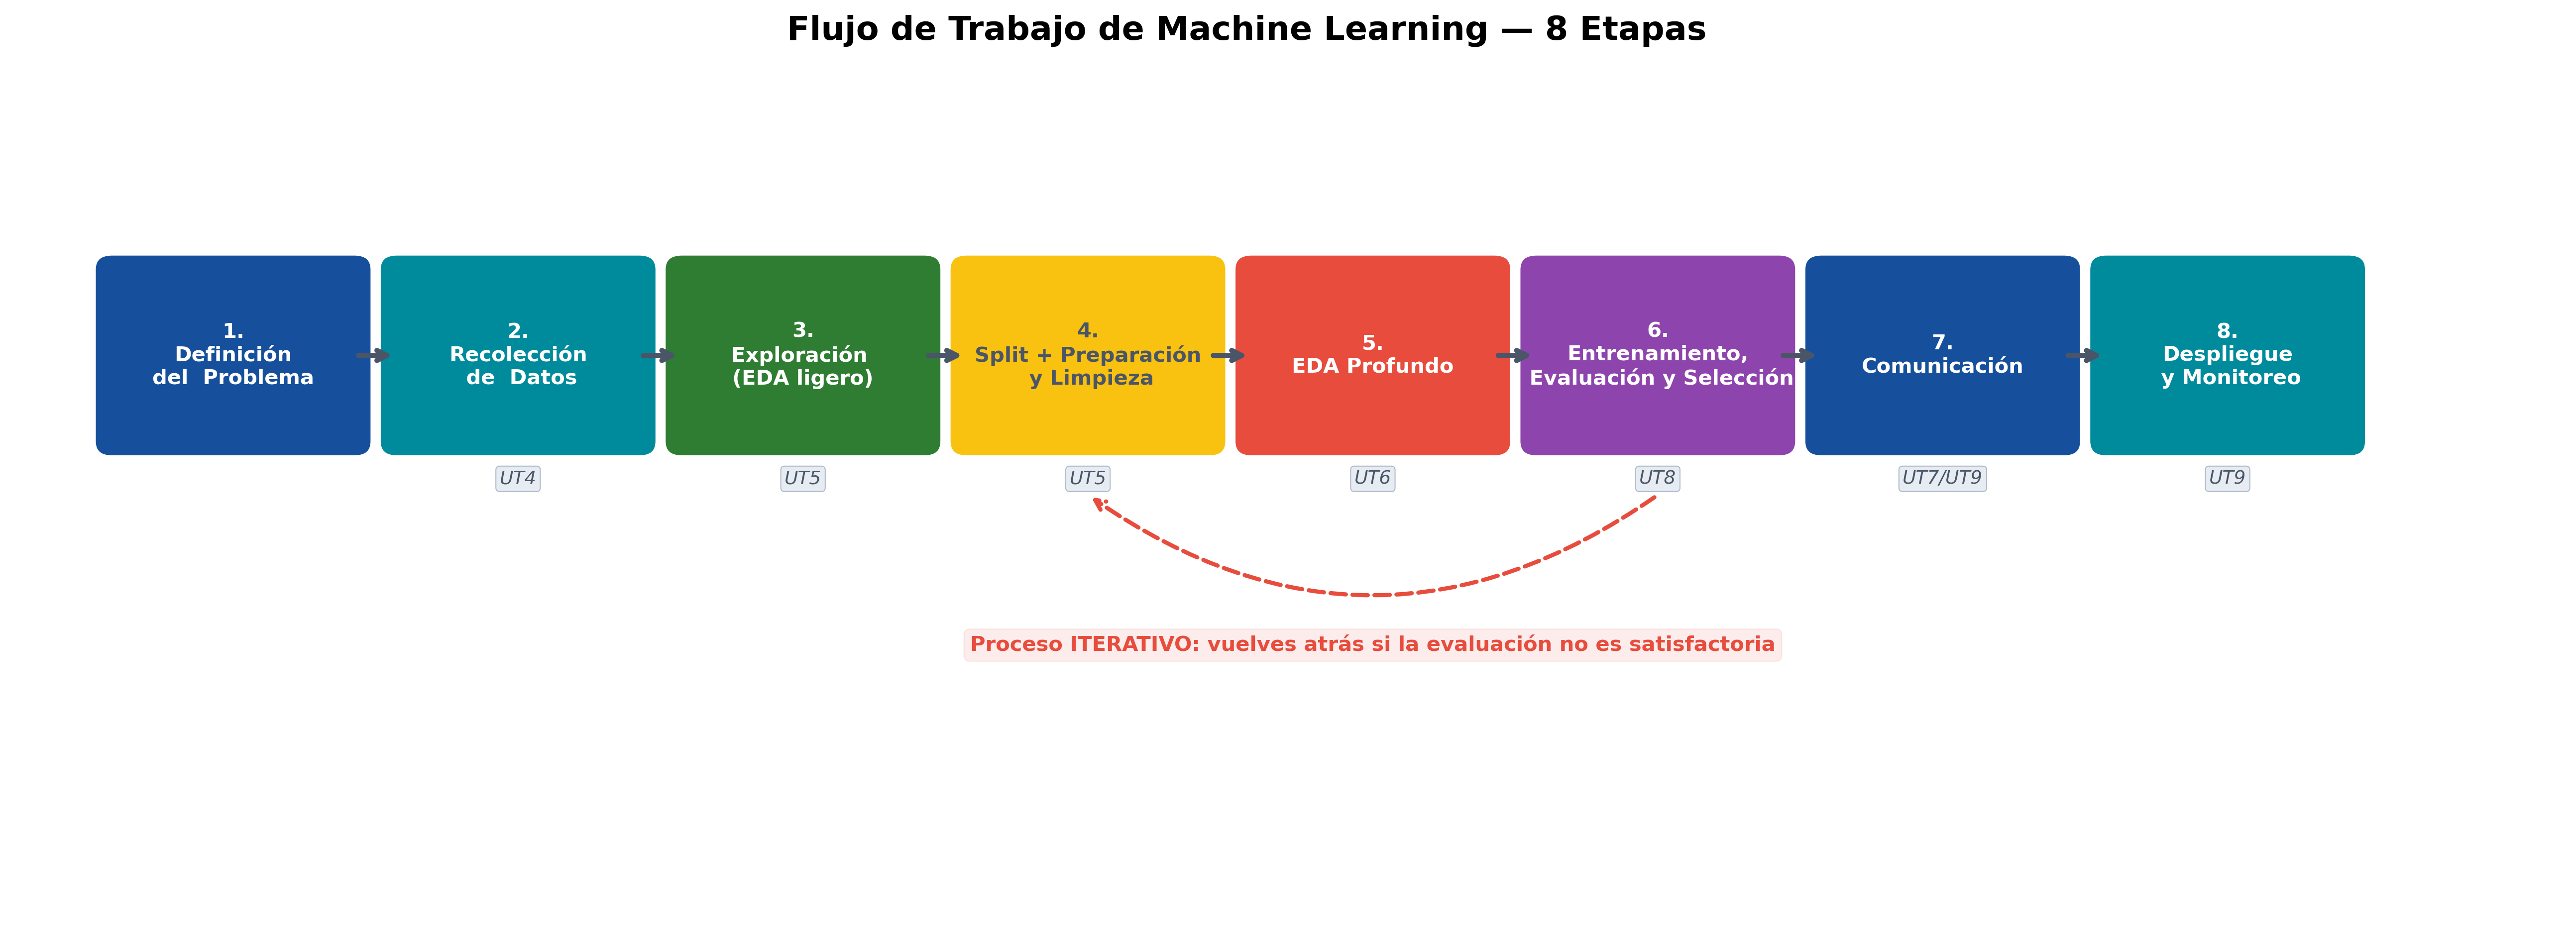
<figcaption aria-hidden="true">Proceso completo</figcaption>
</figure>

## Caso práctico: predicción de precios en Ames, Iowa

A lo largo de la unidad has clasificado viviendas en precio alto o bajo.
Aquí abordamos la tarea complementaria: predecir el precio exacto como
valor continuo. Los mismos datos, el mismo *split*, tres algoritmos de
regresión — incluyendo `DecisionTreeRegressor` y
`RandomForestRegressor`, que ya conoces como clasificadores pero que
funcionan igual de bien para problemas de regresión. Así completarás el
cuadro: los cuatro modelos del libro aplicados a los dos tipos de
problema supervisado.

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15,
                                n_jobs=-1, random_state=42).fit(X_train, y_train)

def _met_reg(modelo, nombre, X_tr=None, X_te=None):
    if X_tr is None: X_tr = X_train
    if X_te is None: X_te = X_test
    yp_te  = modelo.predict(X_te)
    yp_tr  = modelo.predict(X_tr)
    yp_e   = np.exp(yp_te)           # back-transform a € para MAE/RMSE
    yte_e  = np.exp(y_test)
    return {
        'Modelo':   nombre,
        'MAE':      int(mean_absolute_error(yte_e, yp_e)),
        'RMSE':     int(mean_squared_error(yte_e, yp_e)**0.5),
        'R²_test':  round(r2_score(y_test, yp_te), 3),    # R² en log (estándar)
        'R²_train': round(r2_score(y_train, yp_tr), 3),
    }

_tabla_reg = pd.DataFrame([
    _met_reg(modelo_lr, 'Regresión Lineal', X_train_lr, X_test_lr),
    _met_reg(dt_reg,    'Árbol de Decisión (depth=5)'),
    _met_reg(rf_reg,    'Random Forest (100 árboles)'),
])

| Modelo                      | MAE       | RMSE      | R²_test | R²_train |
|:----------------------------|:----------|:----------|--------:|---------:|
| Regresión Lineal            | 19,704 \$ | 27,831 \$ |   0.852 |    0.857 |
| Árbol de Decisión (depth=5) | 23,055 \$ | 33,826 \$ |   0.795 |    0.837 |
| Random Forest (100 árboles) | 18,706 \$ | 26,838 \$ |   0.846 |    0.978 |

Comparación de modelos de regresión sobre Ames Housing (mismo *split*
80/20).

La columna `R²_train` añade el diagnóstico que `R²_test` oculta. La
Regresión Lineal apenas difiere entre entrenamiento y test (0.857 →
0.852): no sobreajusta. El Random Forest, en cambio, memoriza el
*training set* con precisión casi perfecta ($R^2_{train} = 0.978$) pero
generaliza solo al $R^2_{test} = 0.846$ — una brecha de 0.132 provocada
por el `max_depth=15`, que permite árboles suficientemente profundos
como para aprender el ruido de los datos de entrenamiento. Esta señal
conecta directamente con la sección de *overfitting* que viene a
continuación.

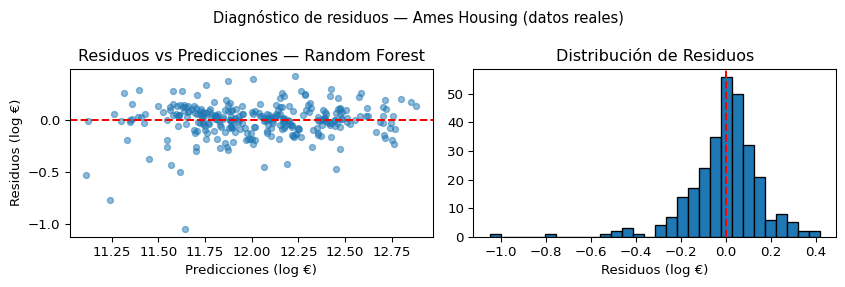

Los residuos tienen mediana +0.009 log-unidades y desviación típica
0.161 log-unidades (equivalente a ±18% de error relativo en precio). La
distribución es simétrica y centrada en cero — señal de que el modelo no
tiene sesgo sistemático. Usar log(precio) como objetivo elimina el
patrón de embudo que aparecería con el precio crudo.

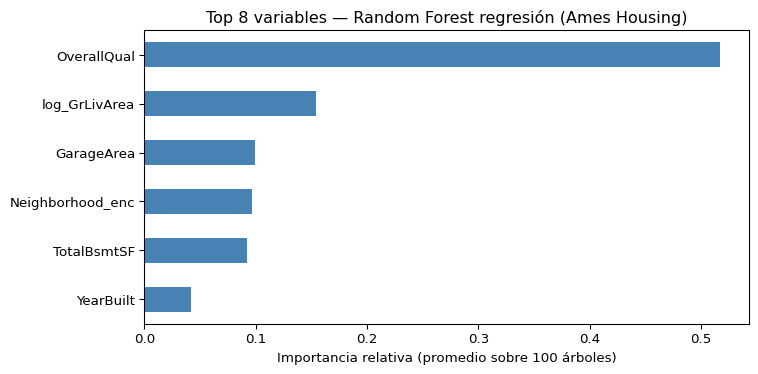

`OverallQual` lidera la importancia del regresor con **0.52** —
coherente con la correlación r = 0,791 identificada en el EDA de UT6 y
con el resultado del clasificador visto anteriormente.

In [67]:
_coefs = (pd.DataFrame({'Variable': FEATURES, 'Coef_log': modelo_lr.coef_})
            .assign(**{'Cambio_%/std': lambda d: (np.exp(d['Coef_log']) - 1) * 100})
            .sort_values('Coef_log', key=abs, ascending=False))

| Variable         | Coef_log | Cambio\_%/std |
|:-----------------|---------:|:--------------|
| log_GrLivArea    |    0.136 | +14.6%        |
| OverallQual      |   0.1019 | +10.7%        |
| Neighborhood_enc |   0.0695 | +7.2%         |
| TotalBsmtSF      |   0.0693 | +7.2%         |
| GarageArea       |   0.0502 | +5.1%         |
| YearBuilt        |   0.0449 | +4.6%         |

Coeficientes de la Regresión Lineal — coeficiente en
log-precio/desv.típica y cambio porcentual equivalente en el precio.

**El EDA predijo lo que el modelo confirma.** `OverallQual` concentra la
mayor importancia del Random Forest — exactamente lo que la correlación
de 0,791 anticipaba en UT6. El modelo no descubre nada nuevo: formaliza
en un número lo que el analista ya intuía en el gráfico.

**La Regresión Lineal bien especificada rinde un $R^2 = 0.852$**. Las
dos variables con mayor peso son `log_GrLivArea` (+14.6%/std) y
`OverallQual` (+10.7%/std) — coherente con el ranking de correlaciones
del EDA de UT6. **Regresión Lineal** lidera en $R^2$ con solo 0.006
puntos de diferencia — un margen que ilustra cómo un modelo lineal bien
especificado puede ser tan competitivo como un ensemble cuando las
variables están bien elegidas.

**`Neighborhood_enc` contribuye 7.19% por desviación típica**: la
localización tiene un efecto real e independiente sobre el precio,
incluso después de controlar por superficie, calidad y antigüedad. Un
modelo bien especificado, sin variables redundantes, permite leer esa
señal con claridad.

El caso práctico compara tres algoritmos sobre Ames Housing con
`log_SalePrice` como objetivo. La Regresión Lineal obtiene $R^2 = 0.852$
y el *Random Forest* obtiene $R^2 = 0.846$ — una diferencia de solo
0.006 puntos.

1.  La Regresión Lineal es competitiva (y en este experimento
    ligeramente superior) al Random Forest. ¿Qué ventaja tiene el Random
    Forest que podría justificar elegirlo en otro contexto? Propón un
    escenario en que un modelo no lineal sea claramente preferible.
2.  El *Random Forest* muestra $R^2_{train} = 0.978$ y
    $R^2_{test} = 0.846$. Sin cambiar de algoritmo, ¿qué ajuste de
    hiperparámetros podría reducir esa brecha de 0.132 puntos?
3.  La tabla de coeficientes muestra que todas las variables tienen un
    peso distinto de cero. ¿Cómo verificarías experimentalmente si
    eliminar `FullBath` o `Neighborhood_enc` perjudica al modelo? ¿Qué
    métrica usarías para comparar y qué umbral considerarías aceptable?

## Conceptos avanzados y próximos pasos

Con los cuatro modelos entrenados y comparados, es el momento de
consolidar los conceptos que subyacen a todos ellos y apuntar hacia
donde continúa el aprendizaje.

### *Overfitting* (sobreajuste) vs. *underfitting* (subajuste): profundización

El rendimiento en el *test set* no siempre refleja el problema real: un
modelo puede parecer bueno si sus métricas de entrenamiento son altas,
pero fallar en producción porque no generalizó. Comprender la diferencia
entre sobreajuste y subajuste es lo que separa a quien evalúa modelos de
quien solo los entrena.

**El objetivo es generalizar:** un buen modelo no es el que mejor se
ajusta a los datos de entrenamiento, sino el que mejor predice datos que
nunca ha visto. Memorizar el *training set* es fácil (basta con un árbol
sin limitar); lo difícil —y lo valioso— es generalizar a datos nuevos.

Piénsalo como tres tipos de estudiante: el que no estudió suficiente
suspende tanto el simulacro como el examen real (*underfitting*); el que
estudió bien aprueba los dos (balance ideal); el que memorizó las
respuestas del simulacro saca 10 en práctica pero suspende el examen
real porque nunca entendió los conceptos (*overfitting*).

**Visualización del concepto:**

<figure>
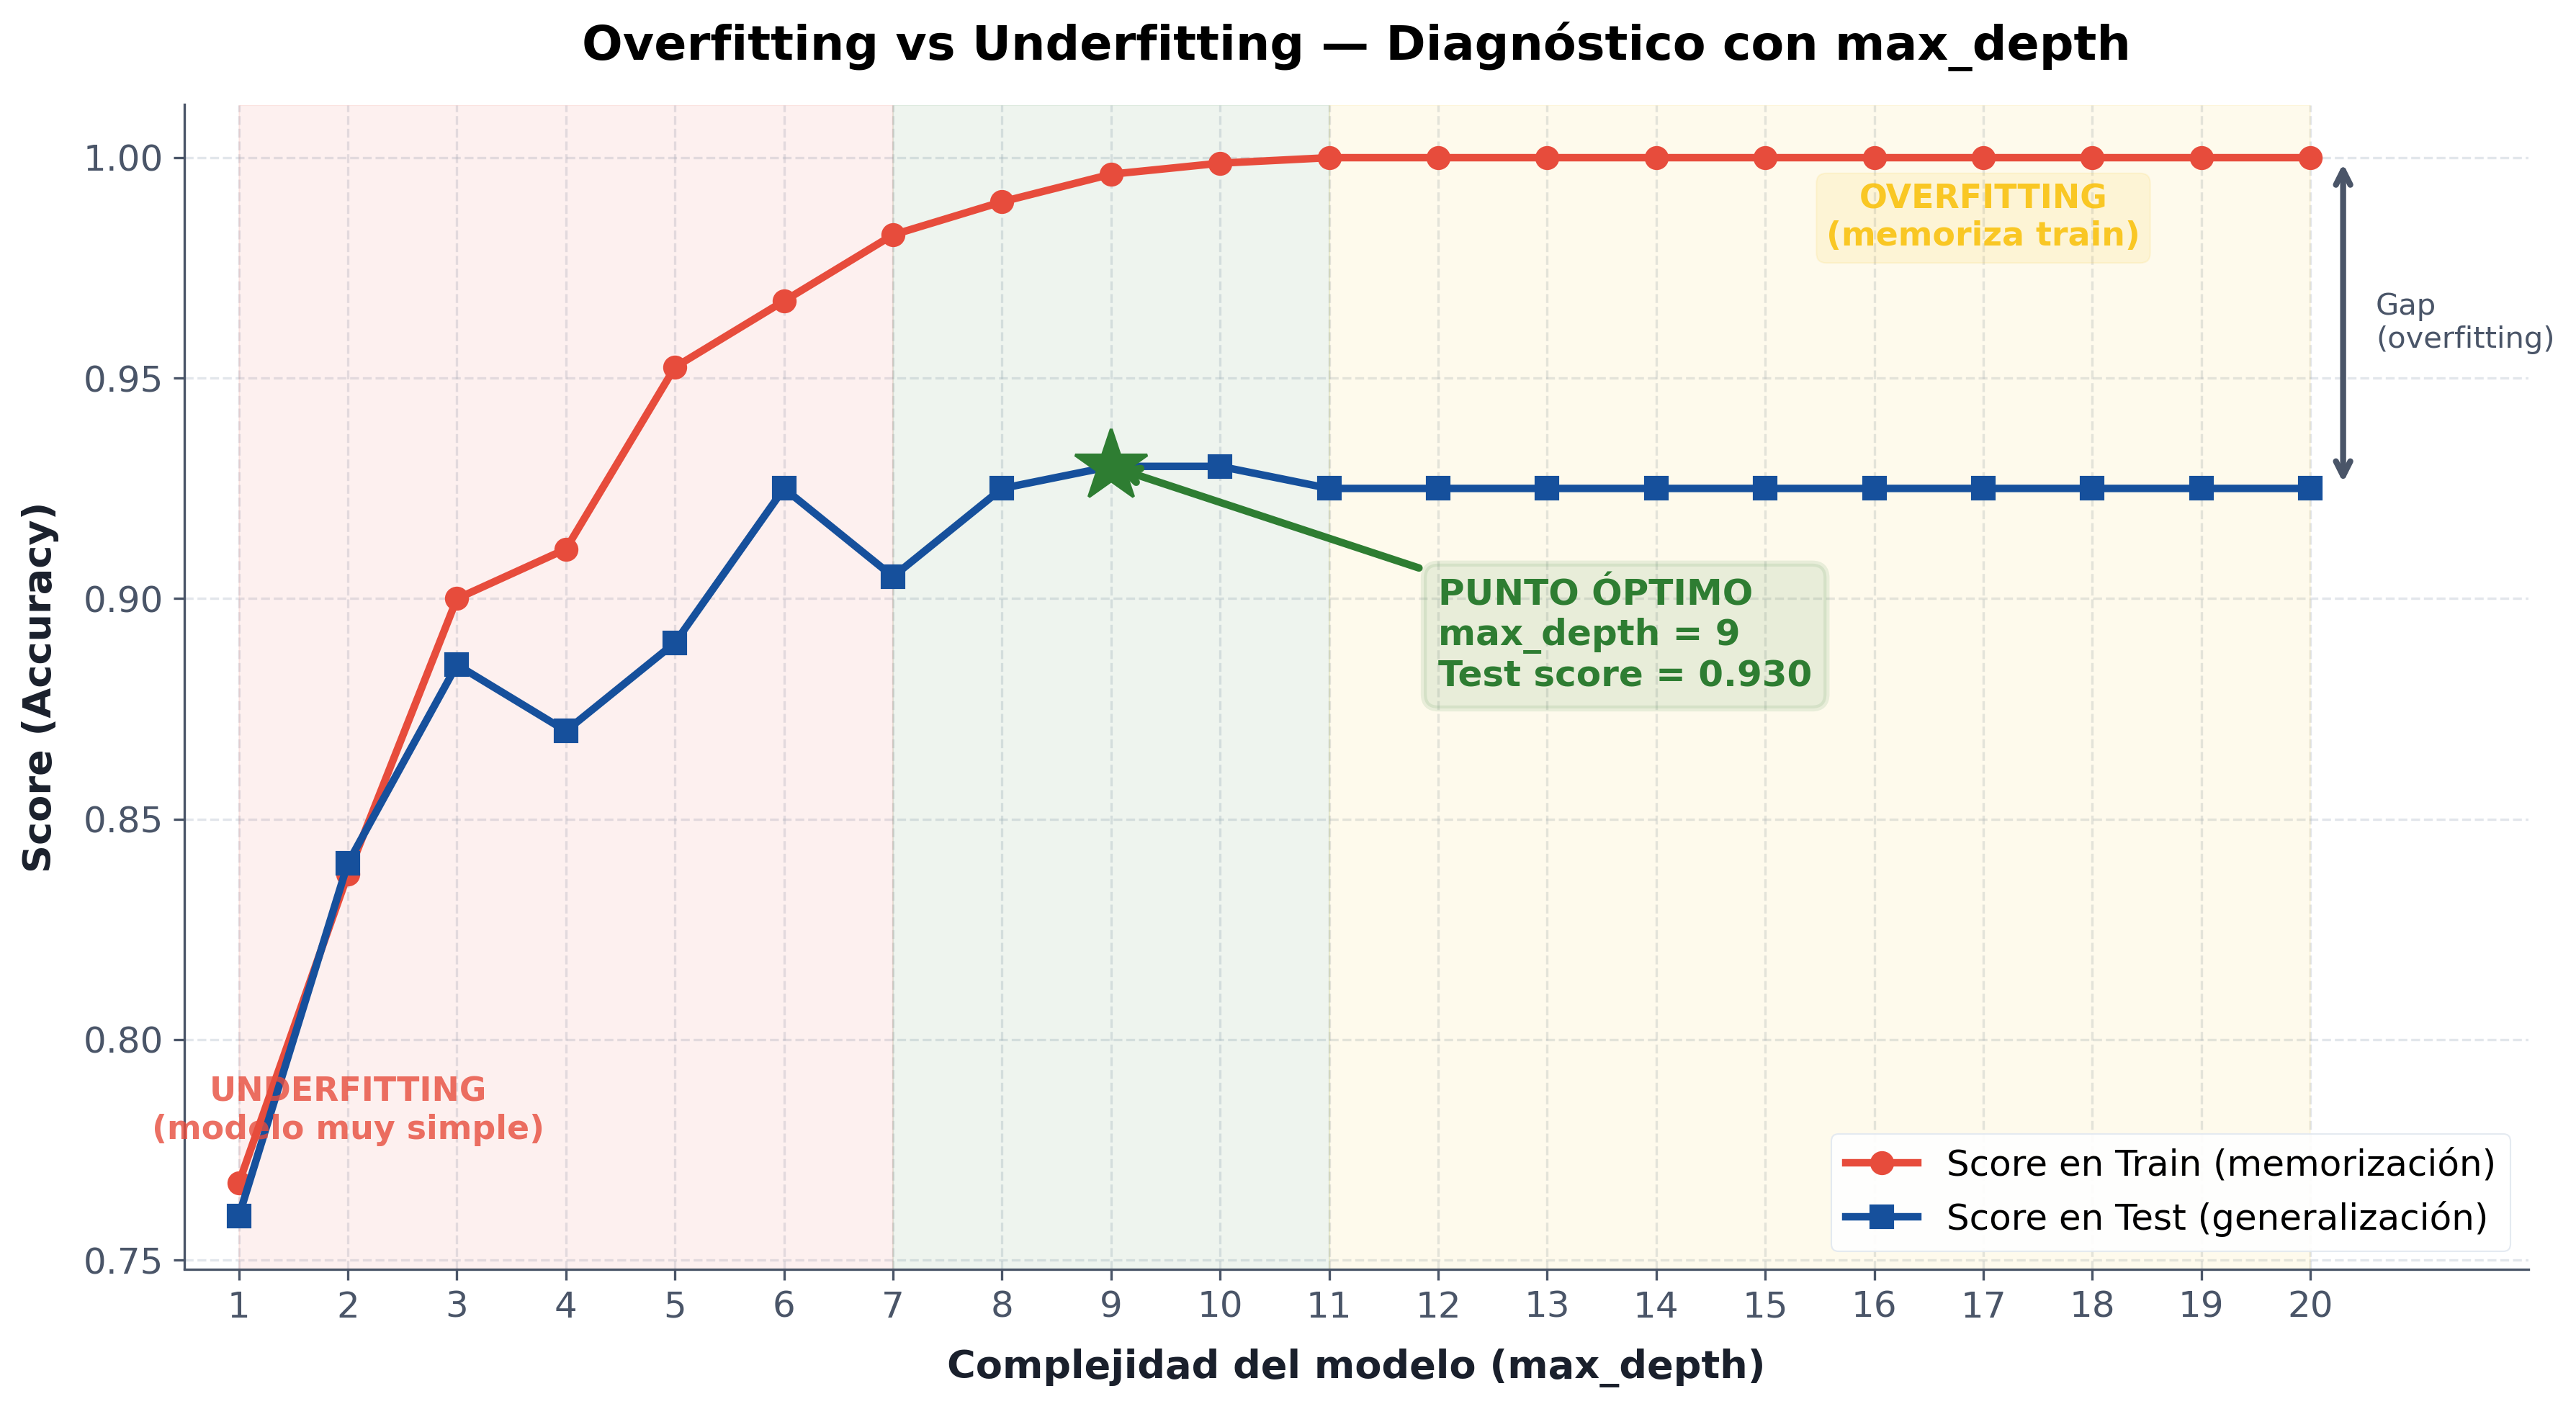
<figcaption aria-hidden="true"><em>Overfitting</em>
vs. <em>underfitting</em>: curvas de rendimiento
<em>train</em>/<em>test</em></figcaption>
</figure>

Para detectarlo, compara `score()` en *train* y en *test*. Una brecha
grande indica *overfitting*; un rendimiento bajo en ambos indica
*underfitting*. Las soluciones dependen del diagnóstico:

| Problema       | Síntoma               | Soluciones                                                          |
|------------------------|------------------------|------------------------|
| *Overfitting*  | Train alto, test bajo | Más datos · reducir `max_depth` · regularización L1/L2 · *ensemble* |
| *Underfitting* | Train y test bajos    | Más *features* · interacciones · modelo más complejo                |

### *cross-validation* (validación cruzada)

Imagina que entrenas un modelo y obtienes un $R^2 = 0{,}91$. ¿Es bueno o
tuviste suerte con el split? Con un único *train/test split*, el
resultado depende de qué ejemplos cayeron en cada partición: si los
casos difíciles van a *train* y los fáciles a *test*, el modelo parece
mejor de lo que es — y al revés.

La **validación cruzada** elimina esa dependencia dividiendo los datos
en $K$ partes (*folds*). En cada iteración, una parte diferente actúa
como *test* y las otras $K-1$ como *train*. Al final se tienen $K$
puntuaciones — una por iteración — cuyo promedio es una estimación mucho
más fiable del rendimiento real, y cuya desviación típica indica cuánto
varía el modelo según los datos que ve.

$$\text{Score\_CV} = \frac{1}{K}\sum_{i=1}^{K} \text{Score}_i$$

En la práctica, $K = 5$ o $K = 10$ es el estándar. Con $K = 5$ entrenas
5 modelos en lugar de 1, por lo que el coste computacional se multiplica
— algo a tener en cuenta con *datasets* grandes o modelos lentos.

**K-fold cross-validation**

In [71]:
from sklearn.model_selection import cross_val_score

# Usamos X_train (no X completo): X_test permanece intocado hasta la evaluación final.
# CV divide X_train en 5 folds — en cada iteración, 4 entrenan y 1 valida.
_cv_scores = cross_val_score(
    modelo_rf,
    X_train, y_train_clf,
    cv=5,
    scoring='accuracy'
)

-   **CV Scores:** \[0.919, 0.88, 0.888, 0.931, 0.901\]  
-   **Media:** 0.904  
-   **Desviación:** 0.019

Una desviación de 0.019 indica un modelo estable. Comparado con el único
*split* 80/20 usado hasta ahora, la media de 5 *folds* (0.904) es una
estimación más robusta del rendimiento real.

La validación cruzada tiene tres usos principales: evaluar si un modelo
es robusto, comparar modelos de forma justa y ajustar hiperparámetros
con `GridSearchCV`.

Entrenas un modelo y obtienes *test accuracy* = 0,84. Tu compañero
entrena el mismo modelo con otro *split* aleatorio y obtiene *test
accuracy* = 0,76.

1.  ¿Cuál de los dos resultados es más fiable para comunicar al cliente?
    ¿Por qué ninguno de los dos es completamente fiable?
2.  Aplicáis *cross-validation* con $K = 5$ y obtenéis scores \[0,81,
    0,83, 0,79, 0,84, 0,82\]. ¿Qué valor reportaríais y cómo
    interpretáis la variabilidad entre *folds*?
3.  ¿Por qué no tiene sentido aplicar *cross-validation* después de
    haber visto el conjunto de *test*?

**Coste computacional:** *cross-validation* multiplica el tiempo de
entrenamiento por $K$. Con $K = 5$, ya estás entrenando 5 modelos en
lugar de 1. Si además lo combinas con `GridSearch` (sección siguiente),
las combinaciones se multiplican rápidamente. En *datasets* grandes con
*Random Forest*, el tiempo puede escalar de minutos a horas. Empieza
siempre con un subconjunto pequeño de datos para verificar que tu código
funciona antes de lanzar la ejecución completa.

### Optimización de hiperparámetros

Hasta ahora has elegido `max_depth` o `n_estimators` manualmente.
Scikit-learn incluye `GridSearchCV`, que prueba automáticamente todas
las combinaciones posibles de hiperparámetros usando *cross-validation*
y devuelve la mejor configuración: por ejemplo, 3 valores de `max_depth`
× 3 valores de `n_estimators` × 5 *folds* = 45 entrenamientos
automáticos. Es el paso natural cuando tienes un modelo prometedor y
quieres ajustarlo con rigor. Su uso detallado queda fuera del alcance de
esta UT — el Apéndice C.7 recoge los principales elementos del flujo de
ML en scikit-learn.

### *Feature engineering*: conectar con el modelo

**Recuerda (UT5):** En UT5 aprendiste las técnicas de *feature
engineering* aplicadas al análisis de datos: transformaciones
logarítmicas (`np.log`), *binning* con `pd.cut`, extracción de
componentes de fechas (`dt.year`, `dt.month`) e interacciones entre
variables. Repasa UT5 si necesitas refrescar la sintaxis.

En el contexto de Machine Learning, el *feature engineering* tiene un
principio adicional crítico: **cualquier transformación que dependa de
los datos debe calcularse solo sobre `X_train` y aplicarse sobre
`X_test`**, nunca al revés. De lo contrario introduces *data leakage*.

La forma más robusta de garantizarlo es usar un `Pipeline` de sklearn,
que aplica cada transformación en el orden correcto y garantiza
automáticamente que los estadísticos se calculan solo sobre *train* al
llamar a `fit()`. Su sintaxis se incluye en el *Cheat Sheet* de
referencia al final del libro.

**El arte del *feature engineering*:** la diferencia entre un modelo
mediocre y uno excelente suele estar en las *features*, no en el
algoritmo. Requiere conocimiento del dominio, creatividad e iteración.
En competiciones de Kaggle, el *feature engineering* marca más
diferencia que la elección del algoritmo.

Tienes un *dataset* de ventas diarias y quieres predecir las ventas del
día siguiente. Planeas crear la *feature* “media de ventas de los
últimos 7 días” (`rolling_mean_7`).

1.  Si calculas `rolling_mean_7` sobre todo el *dataset* antes de hacer
    el *train/test split*, ¿qué problema introduces? ¿Cómo se llama este
    error?
2.  ¿Cuál es el orden correcto de operaciones para calcular
    `rolling_mean_7` sin contaminar el *test set*?
3.  Propón otras dos *features* derivadas de la fecha (p. ej.
    `dia_semana`) que podrían mejorar el modelo. ¿Por qué aportarían
    información que no está ya en la fecha original?

### Interpretabilidad y explicabilidad

Saber *qué variables* usa el modelo es solo el primer nivel de
comprensión. En muchos contextos se necesita explicar *por qué* el
modelo tomó una decisión concreta para una instancia específica. A
medida que los modelos ganan potencia predictiva, su comportamiento
interno se vuelve más difícil de examinar. En contextos críticos —
medicina, justicia, crédito — esta opacidad tiene consecuencias legales
y éticas reales. Las herramientas más extendidas para abordarlo son
**SHAP** (cuantifica la contribución de cada *feature* a cada predicción
individual), **LIME** (explica una predicción concreta aproximando el
modelo complejo con uno simple localmente) y los ***partial dependence
plots*** (muestran el efecto de una *feature* manteniendo las demás
constantes). Todas ellas quedan fuera del alcance de esta UT pero son
una lectura recomendada al terminar el módulo.

### Ética y sesgos en *Machine Learning*

La interpretabilidad técnica no resuelve por sí sola el problema más
profundo: un modelo estadísticamente impecable puede ser profundamente
injusto. Los modelos de ML pueden perpetuar y amplificar los sesgos
presentes en los datos históricos con los que se entrenan. Estos casos
reales ilustran el problema:

1.  **Sistema de contratación de Amazon:** discriminaba contra mujeres
    porque fue entrenado con CV históricos (mayoría hombres en
    tecnología).

2.  **COMPAS (predicción de reincidencia criminal):** clasificaba
    erróneamente a afroamericanos como alto riesgo el doble que a
    blancos.

3.  **Reconocimiento facial:** mayor tasa de error con personas de piel
    oscura.

4.  **Concesión de préstamos:** modelos entrenados con datos históricos
    que reflejan discriminación por zona geográfica o barrio, lo que
    perpetúa la exclusión financiera en esas mismas áreas.

Los sesgos se originan de tres fuentes principales:

-   Los datos históricos reflejan desigualdades sociales previas.
-   Variables *proxy* que codifican información protegida indirectamente
    (el código postal puede actuar como *proxy* del origen étnico o el
    nivel socioeconómico).
-   *Features* correlacionadas con grupos protegidos sin ser la variable
    protegida en sí.

Como científico de datos tienes la responsabilidad de:

1.  **Auditar y evaluar por grupos:** comprueba que los datos son
    representativos y que el modelo no rinde peor para ningún colectivo.
2.  **Evitar variables *proxy*:** detecta *features* que codifican
    indirectamente información demográfica protegida.
3.  **Documentar limitaciones e involucrar a humanos:** sé honesto sobre
    lo que el modelo no puede hacer; en contextos críticos, la decisión
    final no puede delegarse a un algoritmo.

**Reflexión ética:** imagina que desarrollas un modelo de *scoring*
crediticio para un banco. El modelo tiene un 92 % de *accuracy*, pero
descubres que rechaza préstamos al doble de tasa para personas de
ciertos códigos postales (que correlacionan con minorías étnicas).
¿Desplegarías el modelo tal cual? ¿Qué pasos tomarías antes de ponerlo
en producción? ¿Quién debería tomar la decisión final?

Si no puedes explicar cómo el modelo toma sus decisiones a las personas
afectadas, no lo despliegues en contextos que afecten vidas: salud,
justicia o crédito.

### *Deployment* y monitoreo

Conocer los sesgos es una responsabilidad ética; desplegar el modelo
correctamente es la responsabilidad técnica que sigue. Entrenar un
modelo es solo el principio. En un entorno profesional, el modelo
entrenado debe desplegarse, monitorearse y reentrenarse cuando los datos
cambian — un fenómeno llamado ***model drift***: el mundo evoluciona y
la distribución de los datos en producción se aleja de la del
entrenamiento. Gestionar ese ciclo de vida completo es el dominio del
***MLOps***, con herramientas como MLflow o Weights & Biases para
versionar modelos y monitorear su rendimiento. Este ámbito queda fuera
del alcance de este módulo, pero es el siguiente paso natural en una
carrera de análisis de datos.

### Próximos pasos en tu aprendizaje

Los algoritmos de esta UT son la base del ML supervisado. Una vez
dominados, los caminos naturales de especialización son: ampliar el
repertorio de algoritmos (SVM, *Gradient Boosting*, XGBoost),
profundizar en interpretabilidad (SHAP, LIME, *partial dependence
plots*) o explorar *Deep Learning* con TensorFlow o PyTorch. La
siguiente unidad (UT9) añade la capa de comunicación: cómo trasladar los
resultados de un modelo a una audiencia no técnica mediante *dashboards*
interactivos con Streamlit — porque un modelo excelente que no puede
explicarse pierde la mayor parte de su valor.

### Reflexión final

En UT5 limpiaste Ames Housing. En UT6 descubriste que la calidad de
construcción y la superficie habitable son los mejores predictores del
precio. En UT7 lo visualizaste. En esta unidad entrenaste un Random
Forest que, con esos mismos datos, alcanza un $R^2 = 0.846$ — es decir,
explica el 84.6 % de la varianza del precio de venta. Un analista sin
modelo ya lo intuyó en UT6 mirando la correlación; el modelo añade la
precisión cuantitativa.

Recuerda tres cosas:

-   **El ML es una herramienta, no magia.** Requiere datos de calidad,
    elección correcta del problema y métricas adecuadas. La mayor parte
    del trabajo en un proyecto real no es modelar, sino preparar y
    entender los datos.
-   **Es un proceso iterativo.** Descubrirás en la evaluación que
    necesitas volver al EDA. Eso no es fallar: es trabajar bien.
-   **Es una responsabilidad.** Tus modelos pueden afectar decisiones
    reales — créditos, diagnósticos, contrataciones. La ética no es
    opcional.

El viaje apenas comienza. El *Machine Learning* es un campo en constante
evolución — los fundamentos que has aprendido aquí son la base sobre la
que se construye todo lo demás.

**Nota final:** las definiciones detalladas de los términos técnicos de
*Machine Learning* (como *overfitting*, *cross-validation*, *data
leakage*, etc.) se encuentran disponibles en el **Glosario Bilingüe** al
final de este libro.

## Fuentes y lecturas recomendadas

**¿Quieres profundizar más?** Consulta la bibliografía detallada, los
enlaces a la documentación oficial y los recursos de aprendizaje para
esta unidad en el **Apéndice B: Fuentes y lecturas recomendadas** al
final de este libro.